In [26]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

H2_HHV_MWH_PER_KG = 39.4 / 1000   # 0.0394 MWh/kg

base_dir = '../Cluster_Output_Araucania/Agglomerative'

runs = {
    'k=3':  f'{base_dir}/Agglomerative_k3/weighted_percentile_timeseries/Araucania_Agglomerative_k3.nc',
    'k=6':  f'{base_dir}/Agglomerative_k6/weighted_percentile_timeseries/Araucania_Agglomerative_k6.nc',
    'k=9':  f'{base_dir}/Agglomerative_k9/weighted_percentile_timeseries/Araucania_Agglomerative_k9.nc',
    'k=12': f'{base_dir}/Agglomerative_k12/weighted_percentile_timeseries/Araucania_Agglomerative_k12.nc',
    # 'k=15': f'{base_dir}/Agglomerative_k15/weighted_percentile_timeseries/Araucania_Agglomerative_k15.nc',
}

tech_to_category = {
    'onshore_wind':                 'Wind',
    'solar_single_axis':            'Solar',
    'electrolyser':                 'Electrolysis',
    'haber_and_air_separation':     'Haber & Air Sep',
    'battery':                      'Battery',
    'fuel_cell':                    'Fuel Cell',
    'compressed_hydrogen_storage':  'H₂ Storage',
    'ammonia_storage':              'NH₃ Storage',
    'dc_transmission':              'Power Transport',
    'hydrogen_pipeline':            'H₂ Transport',
    'ammonia_pipeline':             'NH₃ Transport',
    'ammonia_ccgt':                 'Ammonia CCGT',
    'hydrogen_ccgt':                'Hydrogen CCGT',
}

all_costs   = {}   # category → cost (k$) per run
total_costs = {}   # total system cost (k$) per run
total_h2    = {}   # total H2 demand (MWh) per run

for label, path in runs.items():
    model = calliope.read_netcdf(path)

    # ── Costs ──────────────────────────────────────────────────────────────
    cost_df = model.results['cost'].to_dataframe().reset_index()
    cost_df['tech']     = cost_df['loc_techs_cost'].str.split('::').str[-1].str.split(':').str[0]
    cost_df['category'] = cost_df['tech'].map(tech_to_category)
    all_costs[label]    = cost_df.groupby('category')['cost'].sum()
    total_costs[label]  = float(model.results.cost.sum())   # k$

    # ── H2 demand (carrier consumption for demand_hydrogen) ────────────────
    carrier_con = model.results['carrier_con'].to_dataframe().reset_index()
    h2_demand   = carrier_con[carrier_con['loc_tech_carriers_con'].str.contains('demand_hydrogen')]
    total_h2[label] = float(h2_demand['carrier_con'].abs().sum())   # MWh

    print(f"✓ {label}: cost={total_costs[label]/1e3:.3f} M$,  H2={total_h2[label]:.0f} MWh")
    del model; gc.collect()

# Build cost matrix (k$)
all_categories = sorted(set().union(*[c.index for c in all_costs.values()]))
cost_matrix = pd.DataFrame(index=all_categories, columns=list(runs.keys()))
for label, costs in all_costs.items():
    for cat in all_categories:
        cost_matrix.loc[cat, label] = costs.get(cat, 0)
cost_matrix = cost_matrix.fillna(0).astype(float)

print("\nData loaded successfully.")

✓ k=3: cost=689.969 M$,  H2=4486687 MWh
✓ k=6: cost=659.466 M$,  H2=4486687 MWh
✓ k=9: cost=634.542 M$,  H2=4486687 MWh
✓ k=12: cost=629.883 M$,  H2=4486687 MWh

Data loaded successfully.


k=3: LCOH = 6.059 $/kg
k=6: LCOH = 5.791 $/kg
k=9: LCOH = 5.572 $/kg
k=12: LCOH = 5.531 $/kg


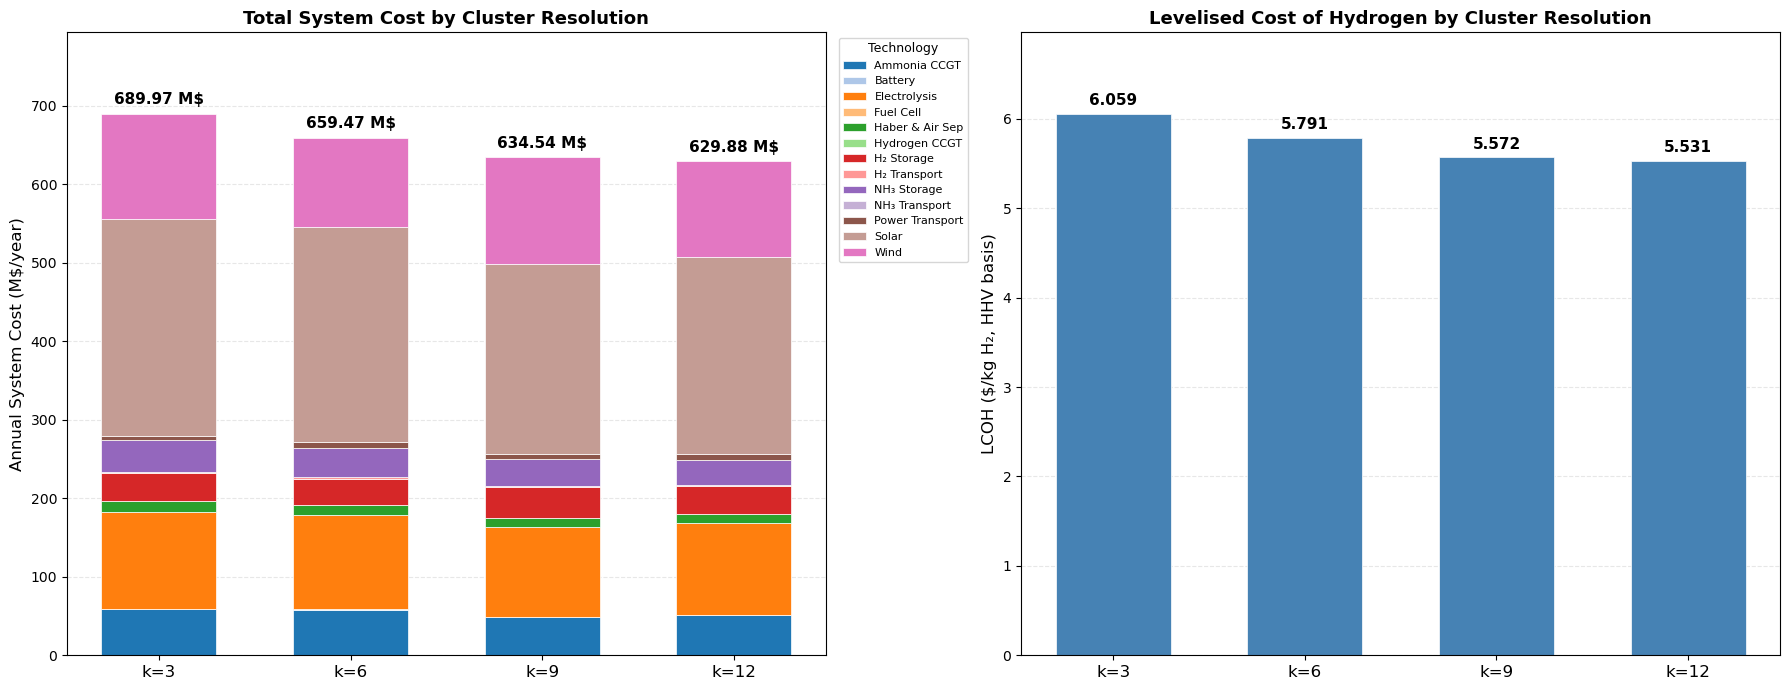

In [27]:
labels     = list(runs.keys())
n          = len(labels)
x          = np.arange(n)
colors     = plt.cm.tab20.colors
cat_colors = {cat: colors[i % len(colors)] for i, cat in enumerate(all_categories)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Total system cost (M$) ──────────────────────────────────────────────
ax = axes[0]
bottom = np.zeros(n)
for cat in all_categories:
    values = cost_matrix.loc[cat].values / 1e3   # k$ → M$
    ax.bar(x, values, bottom=bottom, label=cat, color=cat_colors[cat],
           edgecolor='white', linewidth=0.5, width=0.6)
    bottom += values

global_max = (cost_matrix.sum() / 1e3).max() * 1.15
for i, label in enumerate(labels):
    total = cost_matrix[label].sum() / 1e3
    ax.text(i, total + global_max * 0.01, f'{total:.2f} M$',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Annual System Cost (M$/year)', fontsize=12)
ax.set_ylim(0, global_max)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_title('Total System Cost by Cluster Resolution', fontsize=13, fontweight='bold')
ax.legend(title='Technology', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title_fontsize=9)

# ── Right: LCOH ($/kg H2, HHV basis) ─────────────────────────────────────────
ax2 = axes[1]
lcoh_vals = []
for label in labels:
    cost_k_dollar   = total_costs[label]        # k$
    h2_mwh    = total_h2[label]           # MWh
    h2_kg     = h2_mwh / H2_HHV_MWH_PER_KG   # kg
    lcoh      = (cost_k_dollar * 1e3) / h2_kg  # $ / kg
    lcoh_vals.append(lcoh)
    print(f"{label}: LCOH = {lcoh:.3f} $/kg")

bars = ax2.bar(x, lcoh_vals, color='steelblue', edgecolor='white', linewidth=0.5, width=0.6)
for i, v in enumerate(lcoh_vals):
    ax2.text(i, v + max(lcoh_vals) * 0.01, f'{v:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=12)
ax2.set_ylabel('LCOH ($/kg H₂, HHV basis)', fontsize=12)
ax2.set_ylim(0, max(lcoh_vals) * 1.15)
ax2.yaxis.grid(True, linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)
ax2.set_title('Levelised Cost of Hydrogen by Cluster Resolution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../Cluster_Output_Araucania/cost_lcoh_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

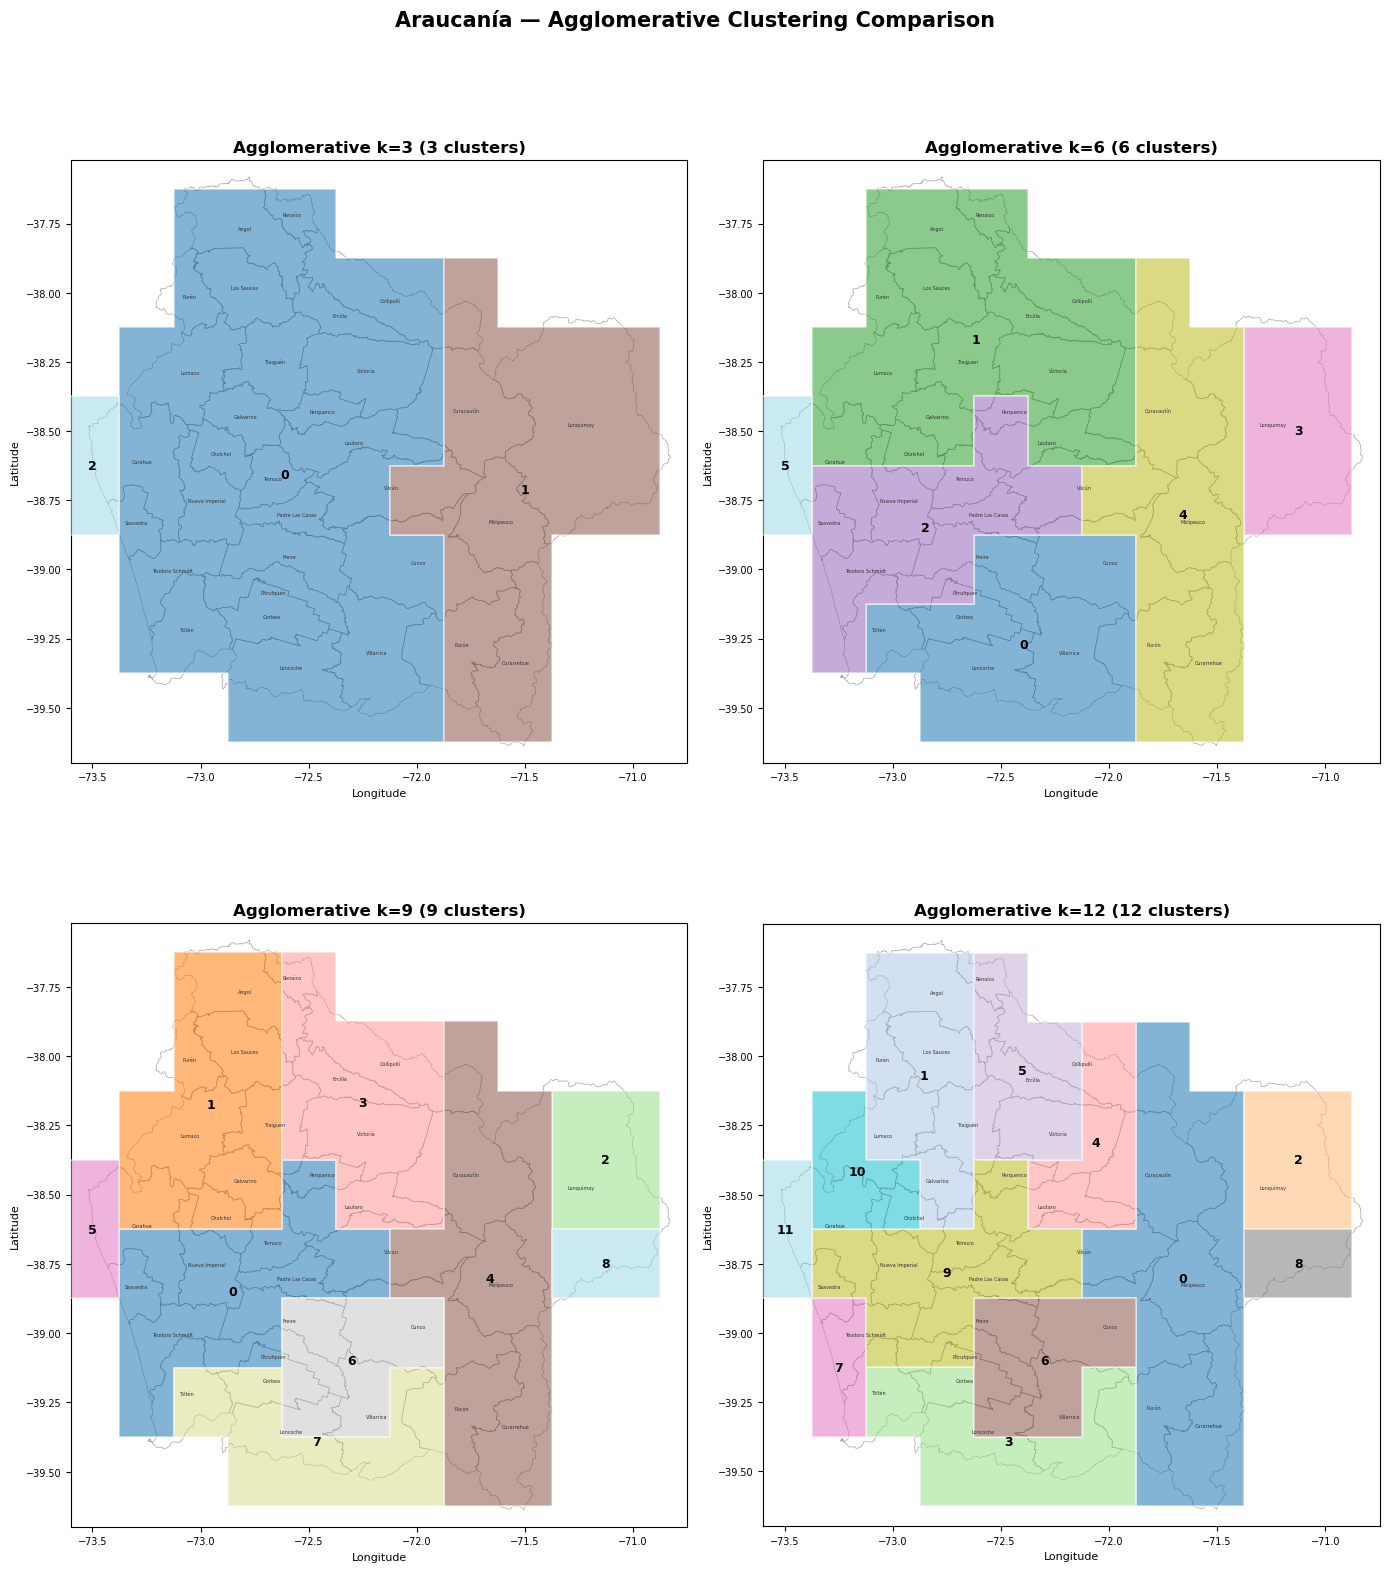

In [28]:
communes = gpd.read_file(
    '../data_Araucania/araucania_communes/araucania_communes.shp'
).to_crs("EPSG:4326")

fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

cmap = plt.cm.tab20

for ax, (label, k_str) in zip(axes, [('k=3','3'), ('k=6','6'), ('k=9','9'), ('k=12','12')]):
    geodata_path = f'{base_dir}/Agglomerative_k{k_str}/clusters_geodata.geojson'
    clusters_gdf = gpd.read_file(geodata_path).to_crs("EPSG:4326")

    n_clusters = clusters_gdf['cluster'].nunique()
    cluster_ids = sorted(clusters_gdf['cluster'].unique())

    # ── Commune outlines ─────────────────────────────────────────────────
    communes.plot(ax=ax, facecolor='none', edgecolor='grey',
                  linewidth=0.5, zorder=2, alpha=0.7)

    # ── Cluster fill (dissolved per cluster for clean boundaries) ─────────
    clusters_dissolved = clusters_gdf.dissolve(by='cluster').reset_index()
    for _, row in clusters_dissolved.iterrows():
        cid   = int(row['cluster'])
        color = cmap(cid / max(cluster_ids))
        gpd.GeoDataFrame([row], geometry='geometry', crs="EPSG:4326").plot(
            ax=ax, facecolor=color, edgecolor='white', linewidth=1.2,
            alpha=0.55, zorder=3
        )
        # Cluster label at centroid
        cx = row.geometry.centroid.x
        cy = row.geometry.centroid.y
        ax.annotate(str(cid), xy=(cx, cy), ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black', zorder=5)

    # ── Commune labels ────────────────────────────────────────────────────
    for _, row in communes.iterrows():
        ax.annotate(row['shapeName'],
                    xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                    ha='center', va='center', fontsize=3.5,
                    color='#333333', zorder=4)

    # ── Extent ────────────────────────────────────────────────────────────
    xmin, ymin, xmax, ymax = communes.total_bounds
    xpad, ypad = (xmax - xmin) * 0.03, (ymax - ymin) * 0.03
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(f'Agglomerative {label} ({n_clusters} clusters)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=8); ax.set_ylabel('Latitude', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Araucanía — Agglomerative Clustering Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Cluster_Output_Araucania/cluster_comparison_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Benhd\AppData\Local\Temp\ipykernel_26316\663092286.py:62: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\Benhd\AppData\Local\Temp\ipykernel_26316\663092286.py:63: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\Benhd\AppData\Local\Temp\ipykernel_26316\663092286.py:62: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\Benhd\AppData\Local\Temp\ipykernel_26316\663092286.py:63: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before th

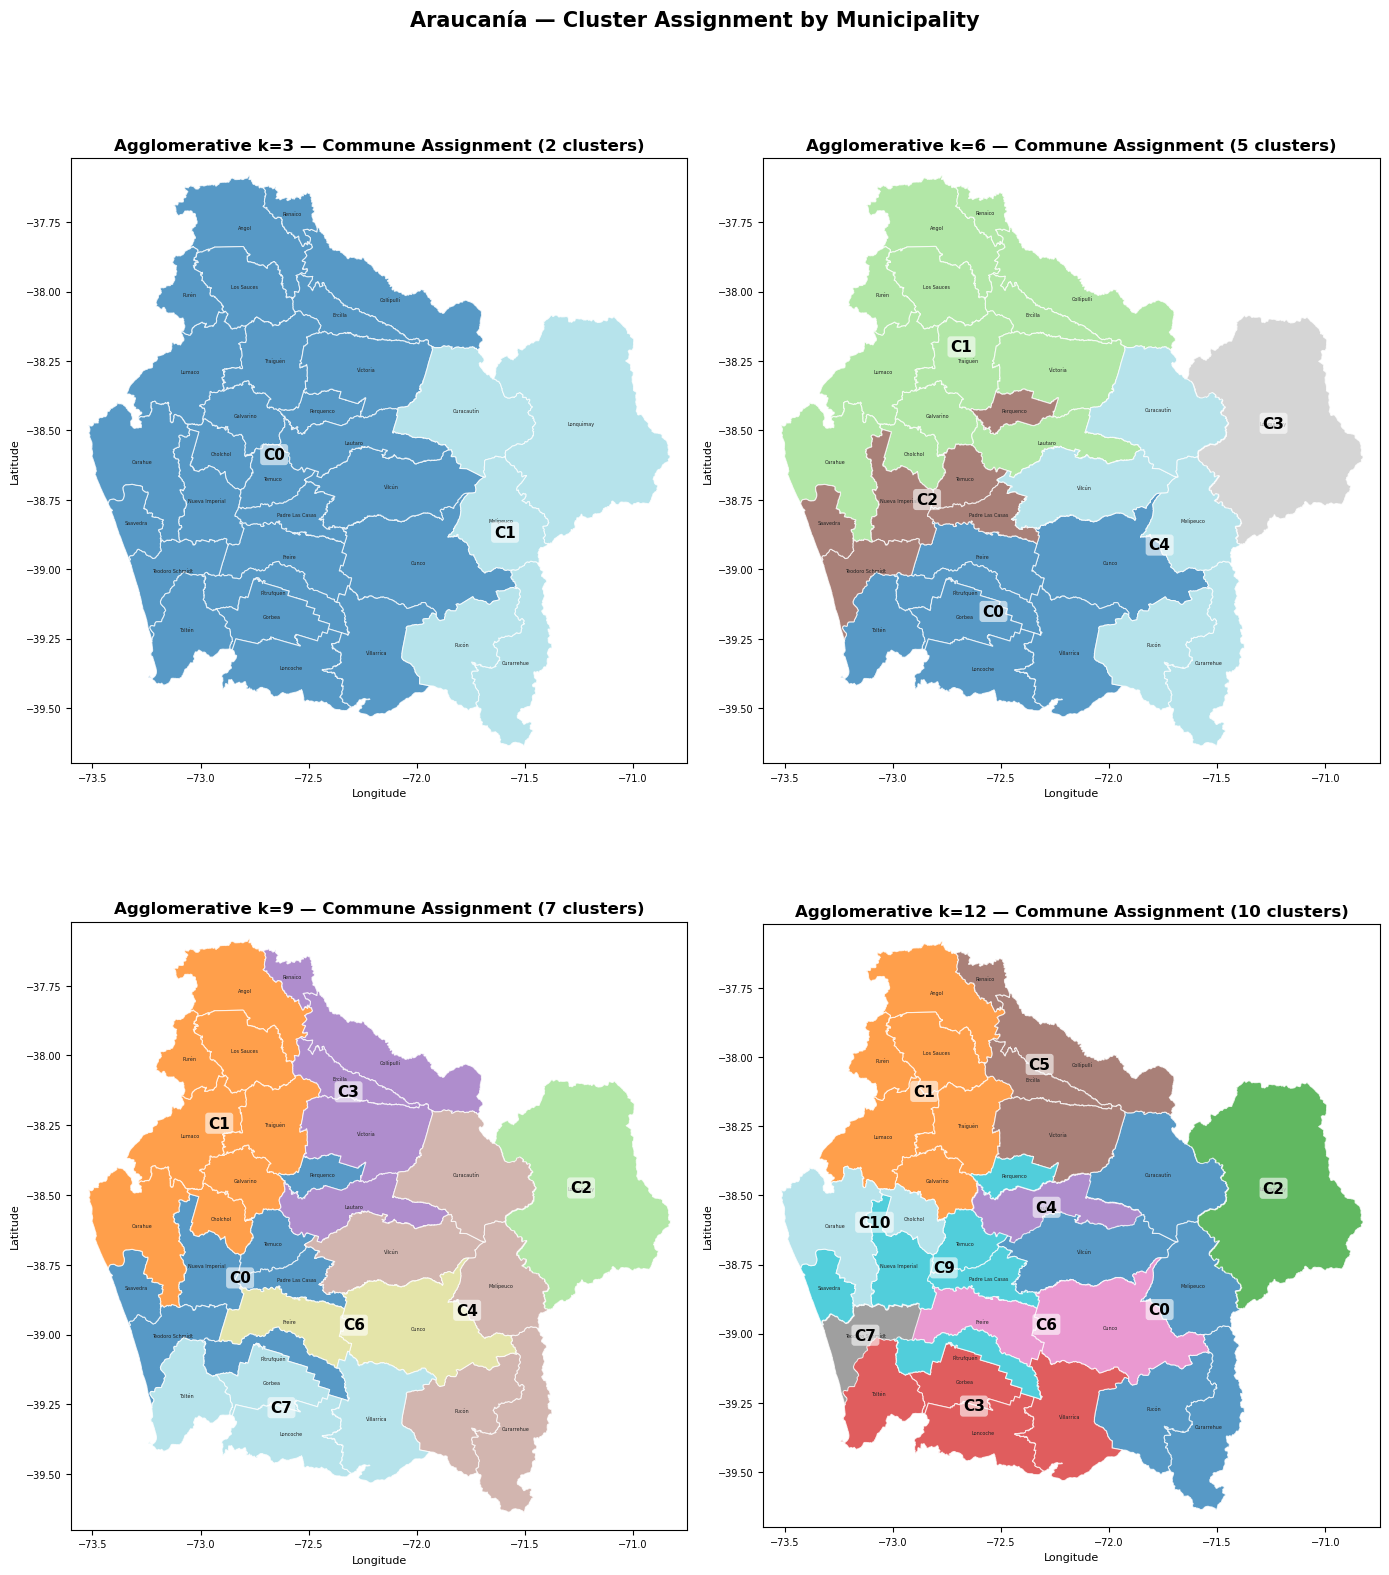

In [29]:
def assign_communes_to_clusters(k_str, communes_gdf):
    """Majority-vote: assign each commune to the cluster covering most of its area."""
    cells = gpd.read_file(
        f'{base_dir}/Agglomerative_k{k_str}/clusters_geodata.geojson'
    ).to_crs("EPSG:32719")[['cluster', 'geometry']]
    communes_m = communes_gdf.to_crs("EPSG:32719").copy()

    # Intersection of commune polygons with cluster grid cells
    intersection = gpd.overlay(communes_m[['shapeName', 'geometry']], cells, how='intersection')
    intersection['area'] = intersection.geometry.area

    # For each commune, pick the cluster with the largest intersecting area
    majority = (
        intersection.groupby(['shapeName', 'cluster'])['area']
        .sum().reset_index()
        .sort_values('area', ascending=False)
        .drop_duplicates('shapeName')
        .set_index('shapeName')['cluster']
    )

    # Fallback for communes with no grid cell overlap: nearest cluster centroid
    cluster_centroids = cells.dissolve(by='cluster').reset_index()
    cluster_centroids['centroid'] = cluster_centroids.geometry.centroid
    for _, row in communes_m[~communes_m['shapeName'].isin(majority.index)].iterrows():
        dists = cluster_centroids['centroid'].distance(row.geometry.centroid)
        majority[row['shapeName']] = int(cluster_centroids.loc[dists.idxmin(), 'cluster'])

    communes_m['assigned_cluster'] = communes_m['shapeName'].map(majority).astype(int)
    return communes_m

communes_wgs = gpd.read_file('../data_Araucania/araucania_communes/araucania_communes.shp')

commune_assignments = {}   # preserved for demand re-aggregation cell

fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()
cmap_local = plt.cm.tab20

for ax, (label, k_str) in zip(axes, [('k=3','3'), ('k=6','6'), ('k=9','9'), ('k=12','12')]):
    communes_assigned = assign_communes_to_clusters(k_str, communes_wgs)
    commune_assignments[k_str] = communes_assigned[['shapeName', 'assigned_cluster']].copy()

    communes_plot = communes_assigned.to_crs("EPSG:4326")
    cluster_ids   = sorted(communes_plot['assigned_cluster'].unique())
    norm          = plt.Normalize(vmin=0, vmax=max(cluster_ids))

    # Communes filled by assigned cluster
    for cid in cluster_ids:
        subset = communes_plot[communes_plot['assigned_cluster'] == cid]
        subset.plot(ax=ax, color=cmap_local(norm(cid)),
                    edgecolor='white', linewidth=0.8, alpha=0.75, zorder=2)

    # Commune name labels
    for _, row in communes_plot.iterrows():
        ax.annotate(row['shapeName'],
                    xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                    ha='center', va='center', fontsize=3.5, color='#222222', zorder=4)

    # Cluster ID label at centroid of each cluster's communes
    for cid in cluster_ids:
        subset = communes_plot[communes_plot['assigned_cluster'] == cid]
        cx = subset.geometry.centroid.x.mean()
        cy = subset.geometry.centroid.y.mean()
        ax.annotate(f'C{cid}', xy=(cx, cy), ha='center', va='center',
                    fontsize=11, fontweight='bold', color='black', zorder=5,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

    xmin, ymin, xmax, ymax = communes_plot.total_bounds
    xpad, ypad = (xmax - xmin) * 0.03, (ymax - ymin) * 0.03
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_title(f'Agglomerative {label} — Commune Assignment ({len(cluster_ids)} clusters)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=8); ax.set_ylabel('Latitude', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Araucanía — Cluster Assignment by Municipality', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Cluster_Output_Araucania/commune_cluster_map_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
import calendar

YEAR = 2023
month_names  = list(calendar.month_name)[1:]   # January … December
month_hours  = [calendar.monthrange(YEAR, m)[1] * 24 for m in range(1, 13)]

demand_df = pd.read_csv('../data_Araucania/60%_H2_Commune_Demand.csv').set_index('month')
# demand_df: rows = month names, cols = commune names (matching shapeName)

results_demand = {}

for k_str in ['3', '6', '9', '12']:
    comm_clust = (commune_assignments[k_str]
                  .set_index('shapeName')['assigned_cluster'].astype(int))

    # Sum monthly MWh per cluster
    monthly_per_cluster = {}
    for commune, cid in comm_clust.items():
        if commune not in demand_df.columns:
            print(f"  Warning: '{commune}' not found in demand CSV — skipping")
            continue
        for month in month_names:
            monthly_per_cluster.setdefault((cid, month), 0.0)
            monthly_per_cluster[(cid, month)] += float(demand_df.loc[month, commune])

    # Expand to 8760-hourly (uniform within each month)
    cluster_ids = sorted(comm_clust.unique())
    rows = []
    for month_idx, month in enumerate(month_names):
        h = month_hours[month_idx]
        for _ in range(h):
            rows.append({
                f'cluster_{cid}': monthly_per_cluster.get((cid, month), 0.0) / h
                for cid in cluster_ids
            })
    hourly_df = pd.DataFrame(rows)

    out_path = f'{base_dir}/Agglomerative_k{k_str}/commune_based_h2_demand_hourly.csv'
    hourly_df.to_csv(out_path, index=False)
    results_demand[k_str] = hourly_df

    # Comparison vs grid-based demand
    grid_demand = pd.read_csv(
        f'{base_dir}/Agglomerative_k{k_str}/cluster_h2_demand_profiles.csv', index_col=0
    )
    print(f"\nk={k_str}  |  Commune-based: {hourly_df.sum().sum():.0f} MWh  |  "
          f"Grid-based: {grid_demand.sum().sum():.0f} MWh")
    for cid in cluster_ids:
        col = f'cluster_{cid}'
        print(f"  Cluster {cid}: {hourly_df[col].sum():.0f} MWh  (commune-based)")

print("\nSaved commune-based hourly demand profiles.")


k=3  |  Commune-based: 113875 MWh  |  Grid-based: -4486687 MWh
  Cluster 0: 109633 MWh  (commune-based)
  Cluster 1: 4243 MWh  (commune-based)

k=6  |  Commune-based: 113875 MWh  |  Grid-based: -4486687 MWh
  Cluster 0: 31542 MWh  (commune-based)
  Cluster 1: 56012 MWh  (commune-based)
  Cluster 2: 16860 MWh  (commune-based)
  Cluster 3: 476 MWh  (commune-based)
  Cluster 4: 8986 MWh  (commune-based)

k=9  |  Commune-based: 113875 MWh  |  Grid-based: -4486687 MWh
  Cluster 0: 19540 MWh  (commune-based)
  Cluster 1: 32270 MWh  (commune-based)
  Cluster 2: 476 MWh  (commune-based)
  Cluster 3: 23741 MWh  (commune-based)
  Cluster 4: 8986 MWh  (commune-based)
  Cluster 6: 14213 MWh  (commune-based)
  Cluster 7: 14649 MWh  (commune-based)

k=12  |  Commune-based: 113875 MWh  |  Grid-based: -4486687 MWh
  Cluster 0: 8986 MWh  (commune-based)
  Cluster 1: 25676 MWh  (commune-based)
  Cluster 2: 476 MWh  (commune-based)
  Cluster 3: 14649 MWh  (commune-based)
  Cluster 4: 6127 MWh  (commune-

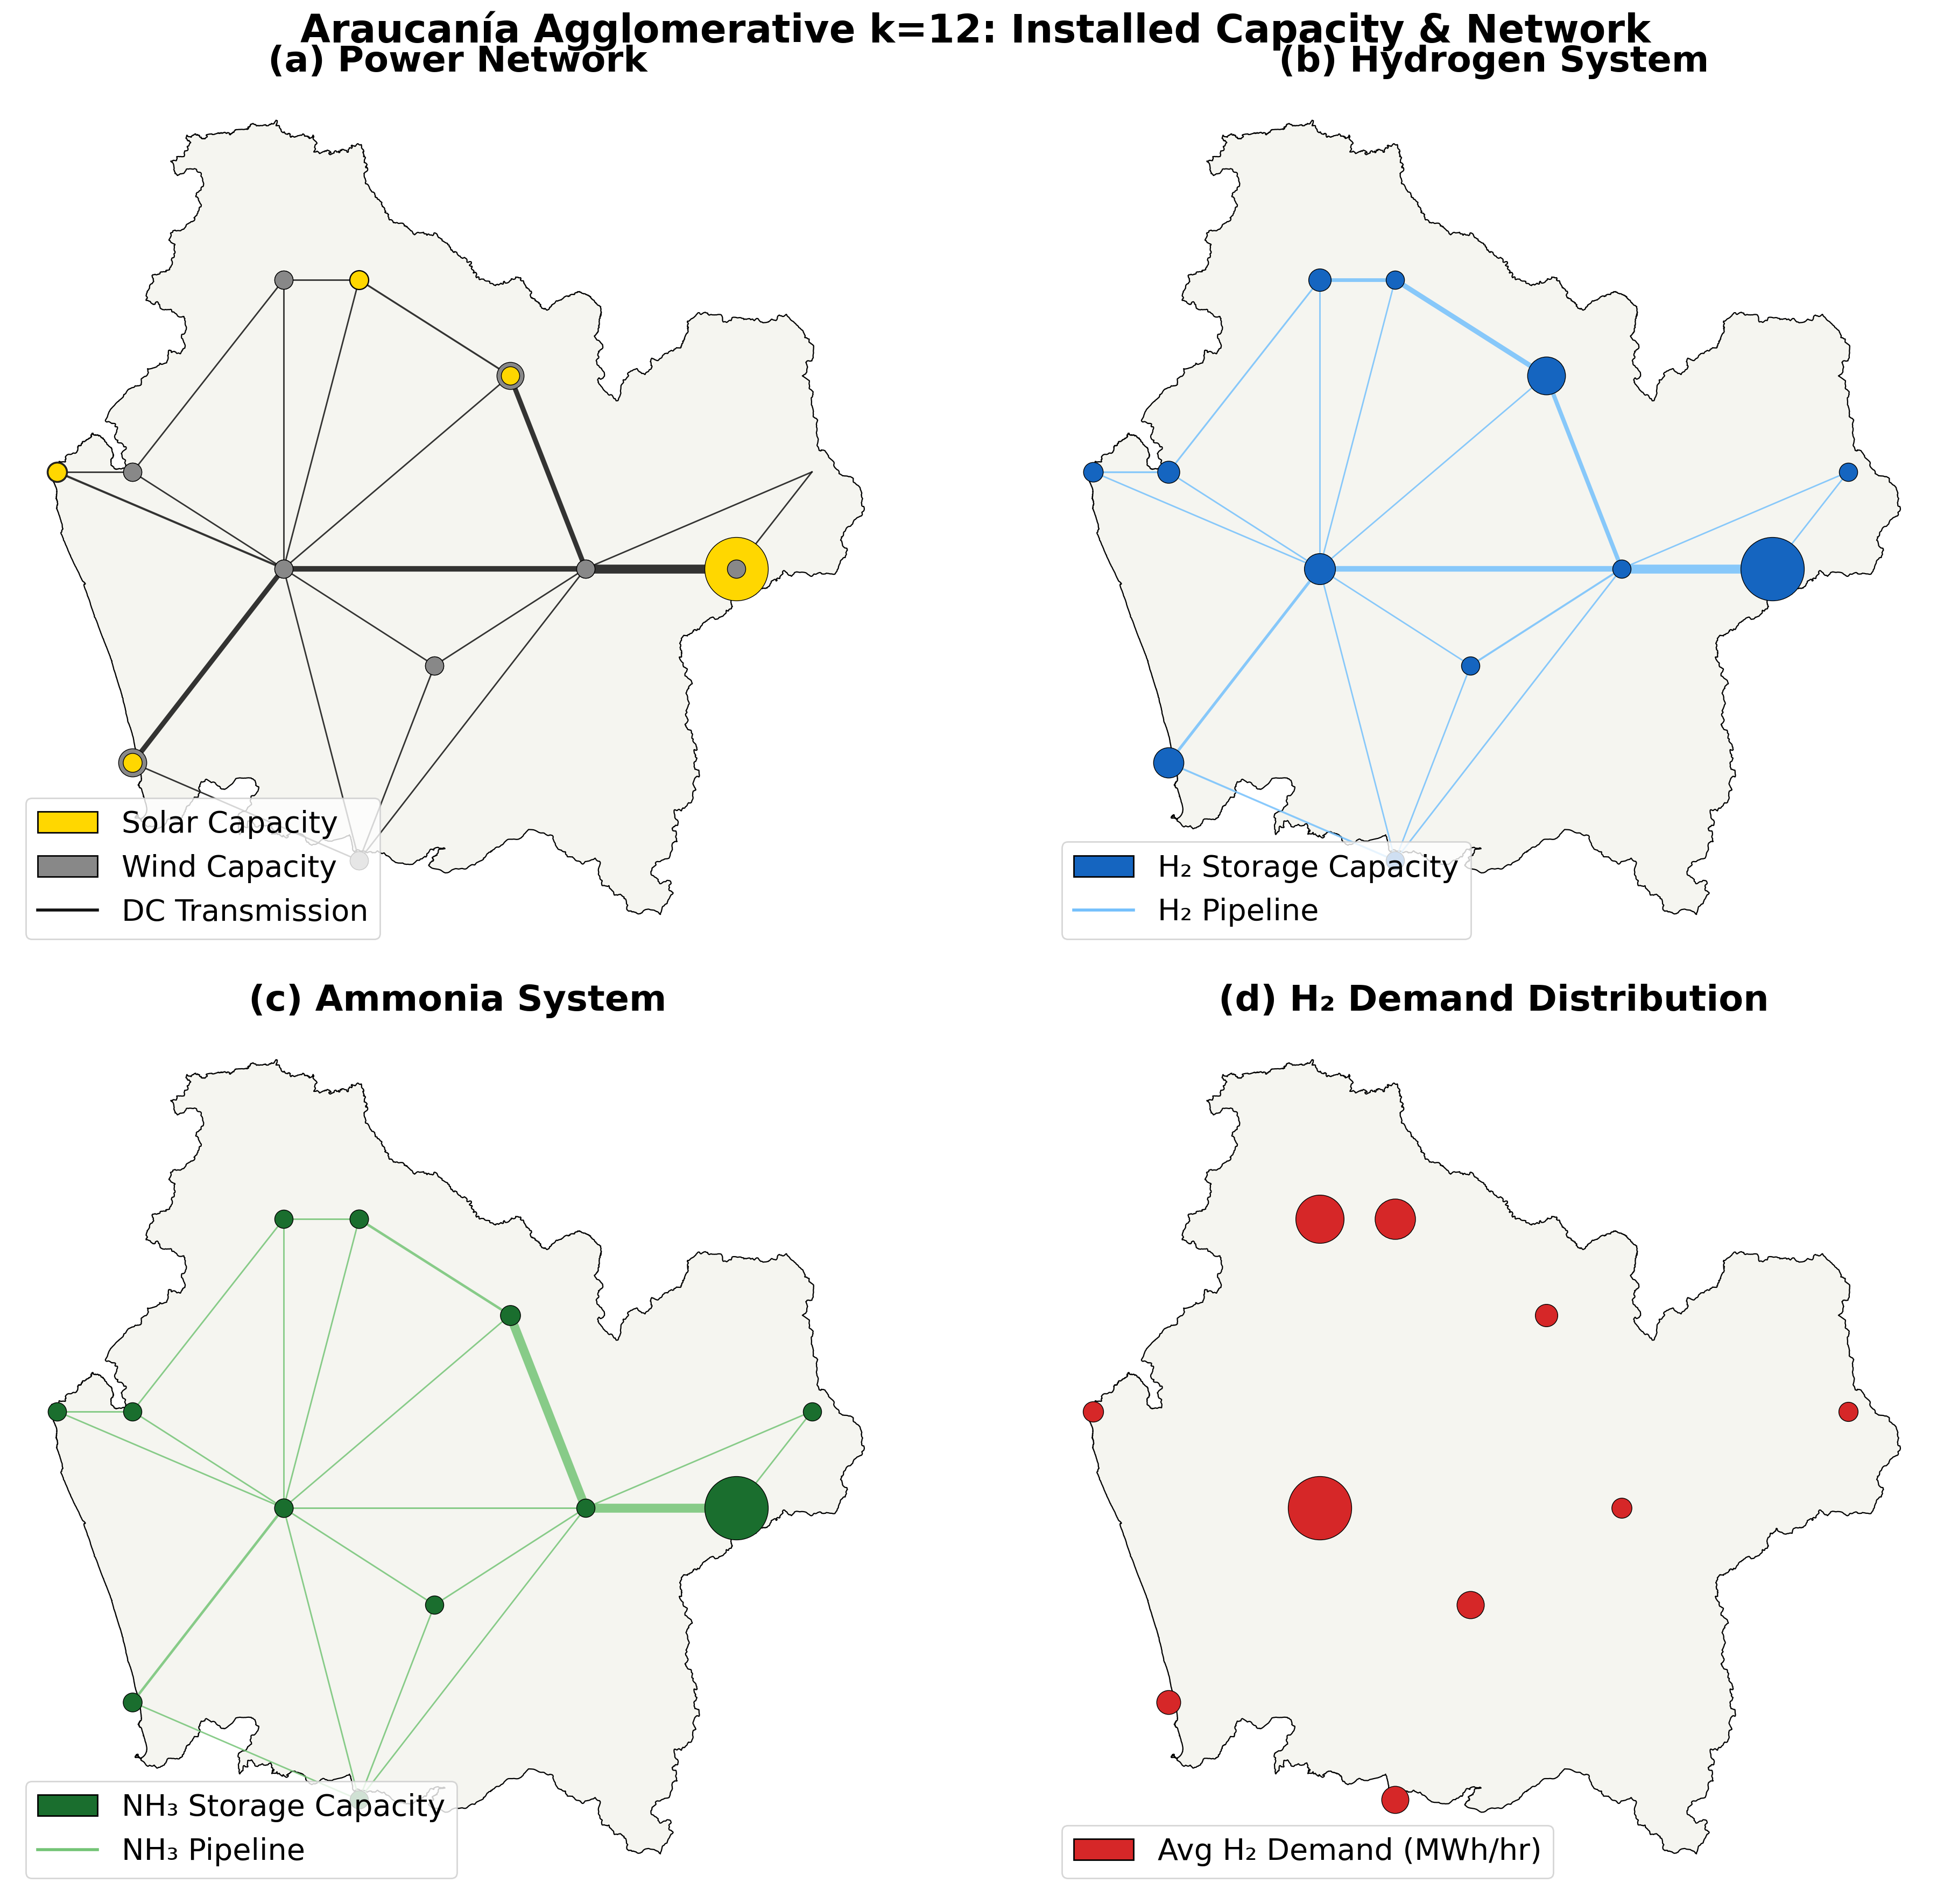

Saved to ../Cluster_Output_Araucania/araucania_k12_capacity_network.png


In [31]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ── Config ──
K_STR = '12'
BASE_ARN      = f'../Cluster_Output_Araucania/Agglomerative/Agglomerative_k{K_STR}'
NC_PATH       = f"{BASE_ARN}/weighted_percentile_timeseries/Araucania_Agglomerative_k{K_STR}.nc"
META_PATH     = f"{BASE_ARN}/cluster_metadata.csv"
BOUNDARY_PATH = '../data_Araucania/CHI_ARN_boundary.geojson'
OUT_PATH      = f'../Cluster_Output_Araucania/araucania_k{K_STR}_capacity_network.png'
CRS = 'EPSG:3857'
MIN_S, MAX_S   = 150, 1800
MIN_LW, MAX_LW = 1, 6.0

# ── Scaling helpers ──
def scale_to_common(series, common_max):
    if common_max == 0:
        return pd.Series(0, index=series.index)
    scaled = MIN_S + (MAX_S - MIN_S) * series.clip(lower=0) / common_max
    return scaled.where(series > 0, 0).clip(upper=MAX_S)

def scale_lw(series):
    mx = series.max()
    if mx == 0:
        return pd.Series(MIN_LW, index=series.index)
    return MIN_LW + (MAX_LW - MIN_LW) * series / mx

# ── Boundary & metadata ──
boundary = gpd.read_file(BOUNDARY_PATH).to_crs(CRS)
meta = pd.read_csv(META_PATH)

def make_node_name(lat, lon):
    return f"region_{str(round(lat, 2)).replace('.', '_')}_{str(round(lon, 2)).replace('.', '_')}"

meta['node_name'] = meta.apply(lambda r: make_node_name(r['lat'], r['lon']), axis=1)

node_gdf = gpd.GeoDataFrame(
    meta.copy(),
    geometry=gpd.points_from_xy(meta['lon'], meta['lat']),
    crs='EPSG:4326'
).to_crs(CRS)
node_gdf['x'] = node_gdf.geometry.x
node_gdf['y'] = node_gdf.geometry.y
node_pos = dict(zip(node_gdf['node_name'], zip(node_gdf['x'], node_gdf['y'])))

# ── Load model results ──
model = calliope.read_netcdf(NC_PATH)

ec_raw = model.results.energy_cap.to_dataframe().reset_index()
ec_raw.columns = ['loc_techs', 'energy_cap']
ec_raw = ec_raw[ec_raw['energy_cap'].notna()].copy()
ec_raw['loc_from']  = ec_raw['loc_techs'].str.split('::').str[0]
ec_raw['tech_rest'] = ec_raw['loc_techs'].str.split('::').str[1]
ec_raw['tech']      = ec_raw['tech_rest'].str.split(':').str[0]
ec_raw['loc_to']    = ec_raw['tech_rest'].apply(
    lambda s: s.split(':', 1)[1] if isinstance(s, str) and ':' in s else None
)
ec_point = ec_raw[ec_raw['loc_to'].isna()][['loc_from', 'tech', 'energy_cap']].rename(
    columns={'loc_from': 'loc'}
).copy()
ec_trans = ec_raw[ec_raw['loc_to'].notna()][['loc_from', 'tech', 'loc_to', 'energy_cap']].copy()
ec_trans['_key'] = ec_trans.apply(
    lambda r: tuple(sorted([r['loc_from'], r['loc_to']])) + (r['tech'],), axis=1
)
ec_trans = (ec_trans.drop_duplicates(subset='_key')
                    .drop(columns='_key')
                    .reset_index(drop=True))
ec_trans = ec_trans[ec_trans['energy_cap'] > 0].reset_index(drop=True)

sc_raw = model.results.storage_cap.to_dataframe().reset_index()
sc_raw.columns = ['loc_techs', 'storage_cap']
sc_raw = sc_raw[sc_raw['storage_cap'].notna()].copy()
sc_raw['loc']  = sc_raw['loc_techs'].str.split('::').str[0]
sc_raw['tech'] = sc_raw['loc_techs'].str.split('::').str[1]

del model; gc.collect()

# ── Drawing helpers ──
def draw_links(ax, tech_name, color):
    df = ec_trans[ec_trans['tech'] == tech_name].copy()
    if df.empty:
        return
    lws = scale_lw(df['energy_cap']).values
    for (_, row), lw in zip(df.iterrows(), lws):
        p1 = node_pos.get(row['loc_from'])
        p2 = node_pos.get(row['loc_to'])
        if p1 and p2:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=lw, zorder=2, alpha=0.85)

def get_point_caps(tech_list):
    return ec_point[ec_point['tech'].isin(tech_list)].groupby('loc')['energy_cap'].sum()

def get_storage_caps(tech_list):
    return sc_raw[sc_raw['tech'].isin(tech_list)].groupby('loc')['storage_cap'].sum()

def draw_two_markers(ax, caps_a, caps_b, col_a, col_b, common_max):
    for node_name, (x, y) in node_pos.items():
        val_a = caps_a.get(node_name, 0)
        val_b = caps_b.get(node_name, 0)
        s_a = scale_to_common(pd.Series([val_a]), common_max).iloc[0]
        s_b = scale_to_common(pd.Series([val_b]), common_max).iloc[0]
        if s_a >= s_b:
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=3)
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=4)
        else:
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=3)
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=4)

def draw_single_markers(ax, caps, color, common_max, zorder=3):
    for node_name, (x, y) in node_pos.items():
        val = caps.get(node_name, 0)
        s = scale_to_common(pd.Series([val]), common_max).iloc[0]
        if s > 0:
            ax.scatter(x, y, s=s, color=color, edgecolors='k', linewidths=0.5, zorder=zorder)

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(20, 18), dpi=200)
fig.suptitle(f'Araucanía Agglomerative k={K_STR}: Installed Capacity & Network',
             fontsize=26, fontweight='bold', y=0.98)

# ── (a) Power Network ──
ax = axes[0, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'dc_transmission', '#111111')
solar_caps = get_point_caps(['solar_single_axis'])
wind_caps  = get_point_caps(['onshore_wind'])
common_max_a = max(solar_caps.max() if not solar_caps.empty else 0,
                   wind_caps.max() if not wind_caps.empty else 0)
draw_two_markers(ax, solar_caps, wind_caps, '#FFD700', '#888888', common_max_a)
ax.set_title('(a) Power Network', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#FFD700', edgecolor='k', label='Solar Capacity'),
    Patch(facecolor='#888888', edgecolor='k', label='Wind Capacity'),
    Line2D([0], [0], color='#111111', linewidth=2, label='DC Transmission'),
], fontsize=20, loc='lower left')

# ── (b) Hydrogen System ──
ax = axes[0, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'hydrogen_pipeline', '#74c0fc')
h2_caps = get_storage_caps(['compressed_hydrogen_storage'])
common_max_b = h2_caps.max() if not h2_caps.empty else 1
draw_single_markers(ax, h2_caps, '#1565C0', common_max_b)
ax.set_title('(b) Hydrogen System', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1565C0', edgecolor='k', label='H₂ Storage Capacity'),
    Line2D([0], [0], color='#74c0fc', linewidth=2, label='H₂ Pipeline'),
], fontsize=20, loc='lower left')

# ── (c) Ammonia System ──
ax = axes[1, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'ammonia_pipeline', '#74c476')
nh3_caps = get_storage_caps(['ammonia_storage'])
common_max_c = nh3_caps.max() if not nh3_caps.empty else 1
draw_single_markers(ax, nh3_caps, '#1a6e2e', common_max_c)
ax.set_title('(c) Ammonia System', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1a6e2e', edgecolor='k', label='NH₃ Storage Capacity'),
    Line2D([0], [0], color='#74c476', linewidth=2, label='NH₃ Pipeline'),
], fontsize=20, loc='lower left')

# ── (d) H₂ Demand Distribution ──
ax = axes[1, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
h2_demand_by_node = meta.set_index('node_name')['avg_h2_demand_MWh'].abs()
dem_max = h2_demand_by_node.max() if not h2_demand_by_node.empty else 1
for node_name, (x, y) in node_pos.items():
    val = h2_demand_by_node.get(node_name, 0)
    s = scale_to_common(pd.Series([val]), dem_max).iloc[0]
    if s > 0:
        ax.scatter(x, y, s=s, color='#d62728', edgecolors='k', linewidths=0.5, zorder=3)
ax.set_title('(d) H₂ Demand Distribution', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#d62728', edgecolor='k', label='Avg H₂ Demand (MWh/hr)'),
], fontsize=20, loc='lower left')

plt.tight_layout(h_pad=2)
plt.savefig(OUT_PATH, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved to {OUT_PATH}")

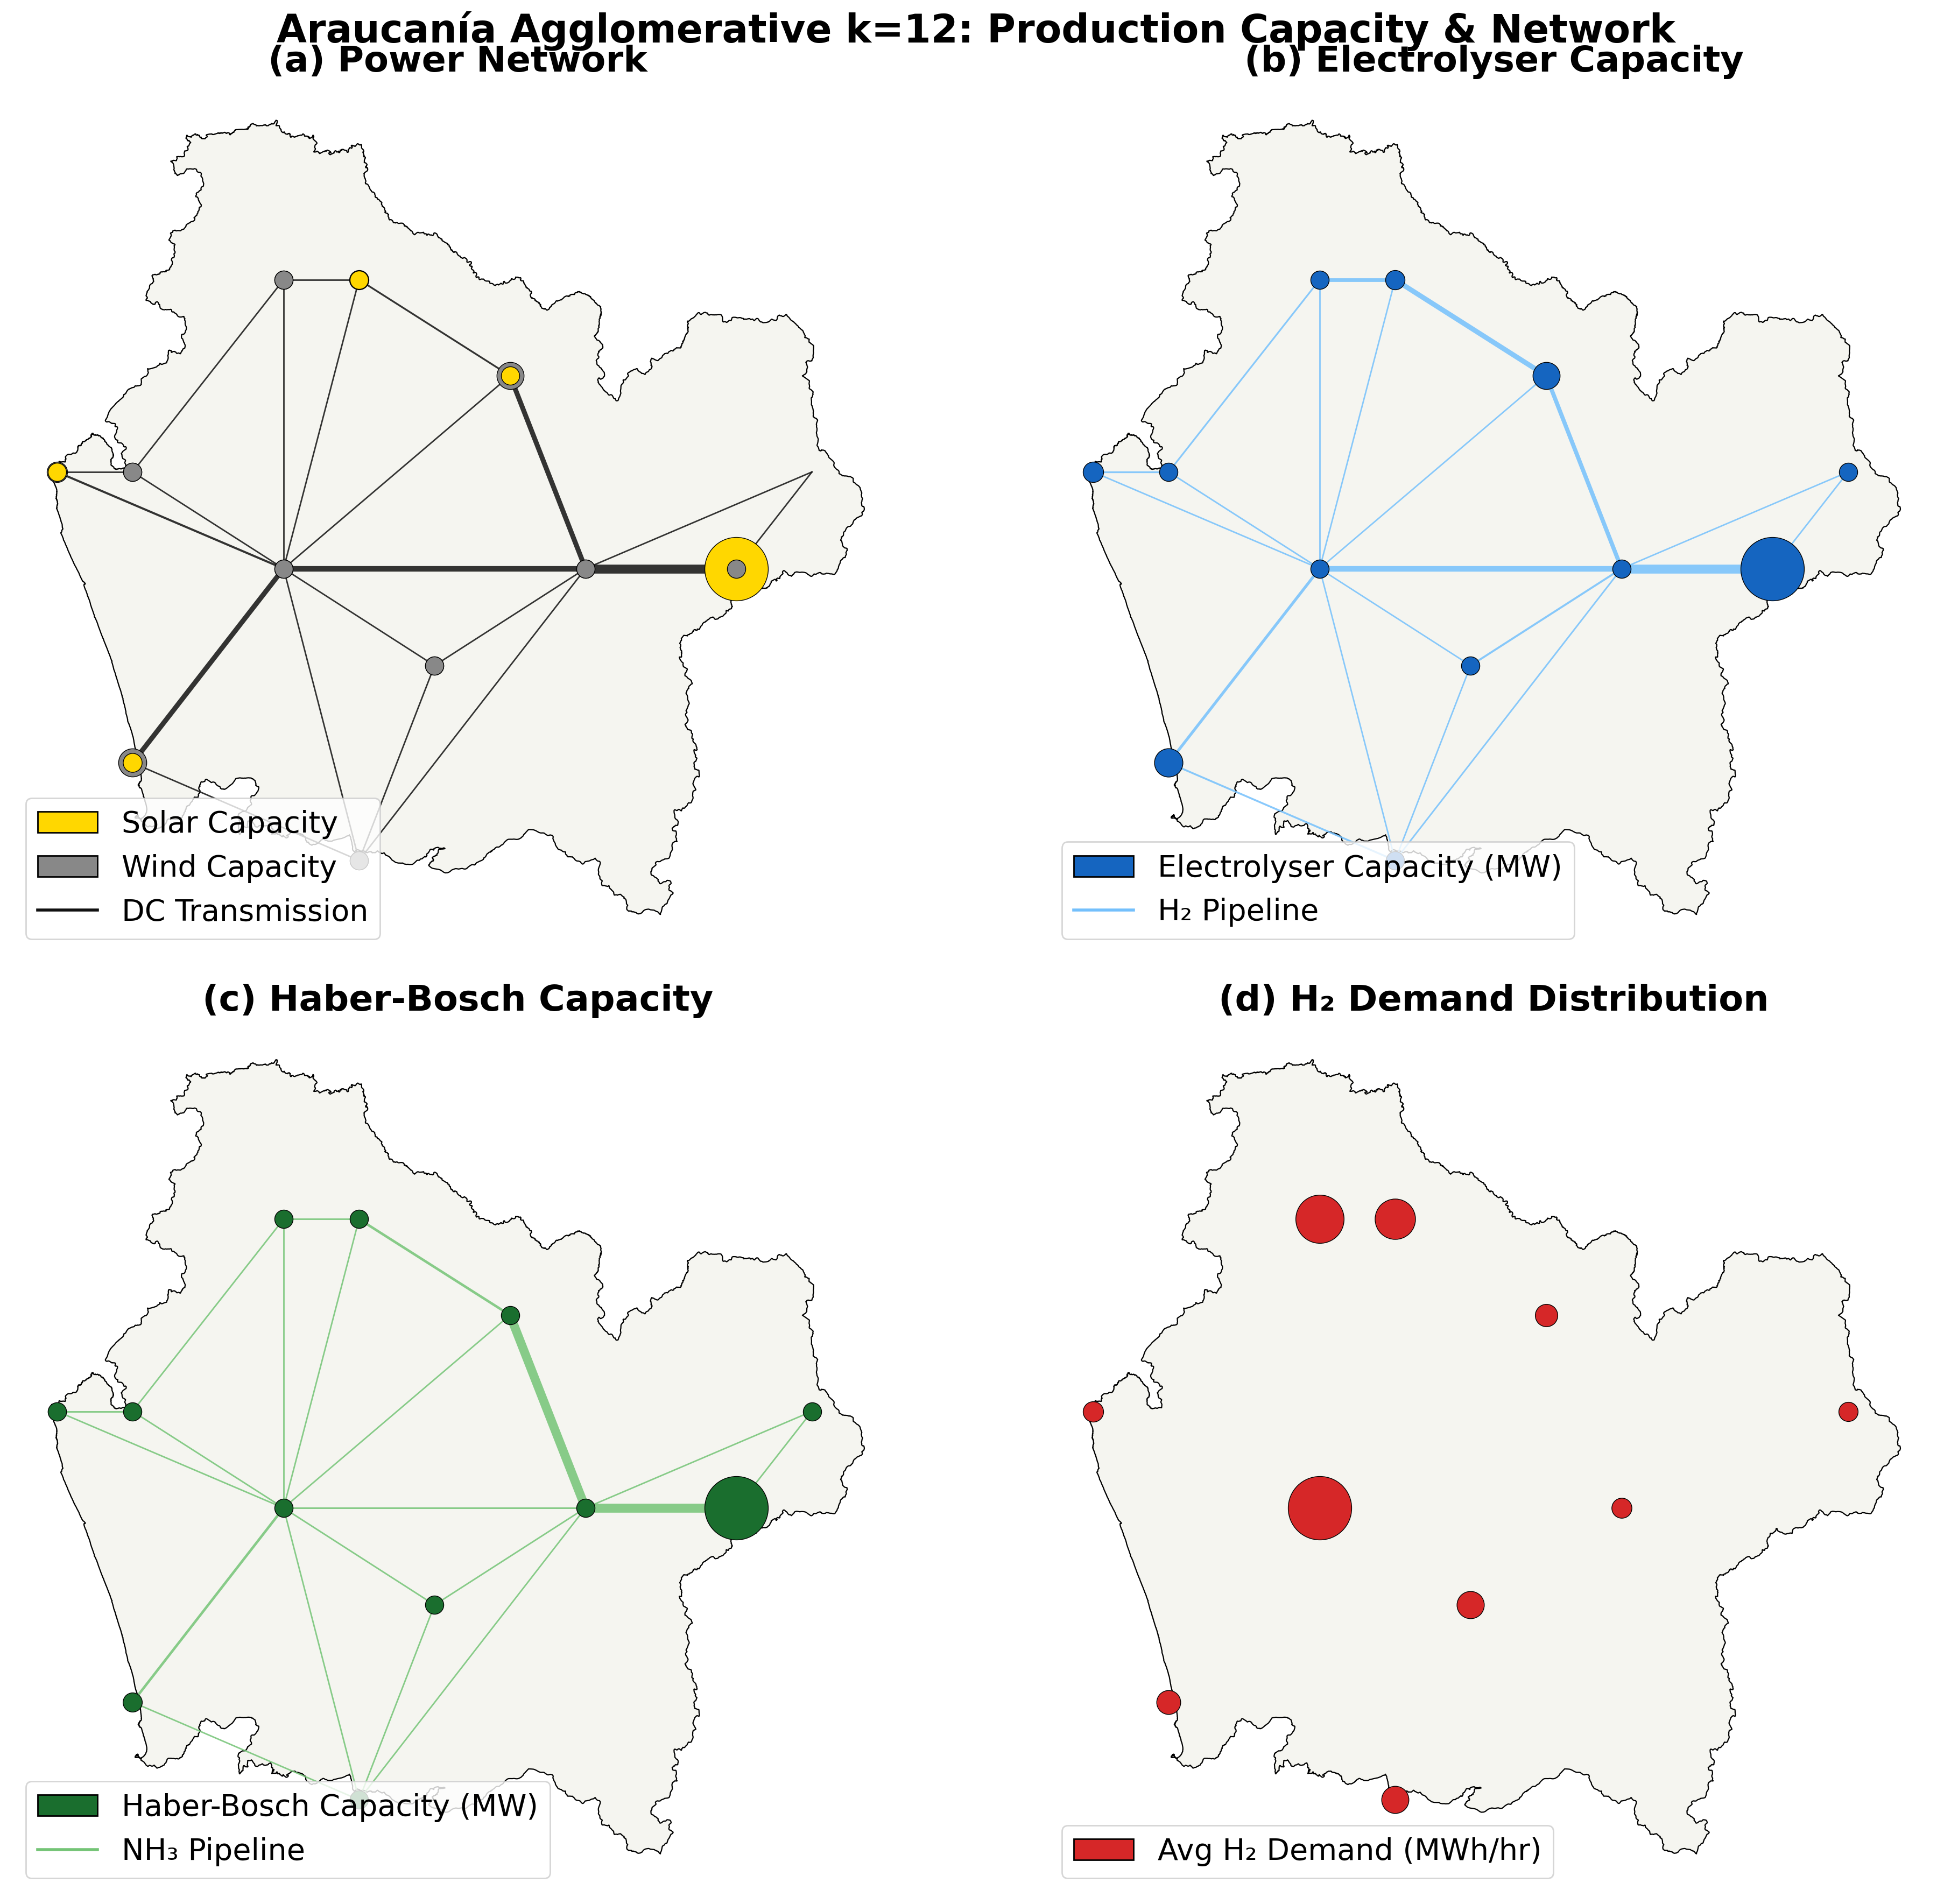

Saved to ../Cluster_Output_Araucania/araucania_k12_production_network.png


In [32]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ── Config ──
K_STR = '12'
BASE_ARN      = f'../Cluster_Output_Araucania/Agglomerative/Agglomerative_k{K_STR}'
NC_PATH       = f"{BASE_ARN}/weighted_percentile_timeseries/Araucania_Agglomerative_k{K_STR}.nc"
META_PATH     = f"{BASE_ARN}/cluster_metadata.csv"
BOUNDARY_PATH = '../data_Araucania/CHI_ARN_boundary.geojson'
OUT_PATH      = f'../Cluster_Output_Araucania/araucania_k{K_STR}_production_network.png'
CRS = 'EPSG:3857'
MIN_S, MAX_S   = 150, 1800
MIN_LW, MAX_LW = 1, 6.0

def scale_to_common(series, common_max):
    if common_max == 0:
        return pd.Series(0, index=series.index)
    scaled = MIN_S + (MAX_S - MIN_S) * series.clip(lower=0) / common_max
    return scaled.where(series > 0, 0).clip(upper=MAX_S)

def scale_lw(series):
    mx = series.max()
    if mx == 0:
        return pd.Series(MIN_LW, index=series.index)
    return MIN_LW + (MAX_LW - MIN_LW) * series / mx

boundary = gpd.read_file(BOUNDARY_PATH).to_crs(CRS)
meta = pd.read_csv(META_PATH)

def make_node_name(lat, lon):
    return f"region_{str(round(lat, 2)).replace('.', '_')}_{str(round(lon, 2)).replace('.', '_')}"

meta['node_name'] = meta.apply(lambda r: make_node_name(r['lat'], r['lon']), axis=1)

node_gdf = gpd.GeoDataFrame(
    meta.copy(),
    geometry=gpd.points_from_xy(meta['lon'], meta['lat']),
    crs='EPSG:4326'
).to_crs(CRS)
node_gdf['x'] = node_gdf.geometry.x
node_gdf['y'] = node_gdf.geometry.y
node_pos = dict(zip(node_gdf['node_name'], zip(node_gdf['x'], node_gdf['y'])))

model = calliope.read_netcdf(NC_PATH)

ec_raw = model.results.energy_cap.to_dataframe().reset_index()
ec_raw.columns = ['loc_techs', 'energy_cap']
ec_raw = ec_raw[ec_raw['energy_cap'].notna()].copy()
ec_raw['loc_from']  = ec_raw['loc_techs'].str.split('::').str[0]
ec_raw['tech_rest'] = ec_raw['loc_techs'].str.split('::').str[1]
ec_raw['tech']      = ec_raw['tech_rest'].str.split(':').str[0]
ec_raw['loc_to']    = ec_raw['tech_rest'].apply(
    lambda s: s.split(':', 1)[1] if isinstance(s, str) and ':' in s else None
)
ec_point = ec_raw[ec_raw['loc_to'].isna()][['loc_from', 'tech', 'energy_cap']].rename(
    columns={'loc_from': 'loc'}
).copy()
ec_trans = ec_raw[ec_raw['loc_to'].notna()][['loc_from', 'tech', 'loc_to', 'energy_cap']].copy()
ec_trans['_key'] = ec_trans.apply(
    lambda r: tuple(sorted([r['loc_from'], r['loc_to']])) + (r['tech'],), axis=1
)
ec_trans = (ec_trans.drop_duplicates(subset='_key')
                    .drop(columns='_key')
                    .reset_index(drop=True))
ec_trans = ec_trans[ec_trans['energy_cap'] > 0].reset_index(drop=True)

del model; gc.collect()

def draw_links(ax, tech_name, color):
    df = ec_trans[ec_trans['tech'] == tech_name].copy()
    if df.empty:
        return
    lws = scale_lw(df['energy_cap']).values
    for (_, row), lw in zip(df.iterrows(), lws):
        p1 = node_pos.get(row['loc_from'])
        p2 = node_pos.get(row['loc_to'])
        if p1 and p2:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=lw, zorder=2, alpha=0.85)

def get_point_caps(tech_list):
    return ec_point[ec_point['tech'].isin(tech_list)].groupby('loc')['energy_cap'].sum()

def draw_two_markers(ax, caps_a, caps_b, col_a, col_b, common_max):
    for node_name, (x, y) in node_pos.items():
        val_a = caps_a.get(node_name, 0)
        val_b = caps_b.get(node_name, 0)
        s_a = scale_to_common(pd.Series([val_a]), common_max).iloc[0]
        s_b = scale_to_common(pd.Series([val_b]), common_max).iloc[0]
        if s_a >= s_b:
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=3)
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=4)
        else:
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=3)
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=4)

def draw_single_markers(ax, caps, color, common_max, zorder=3):
    for node_name, (x, y) in node_pos.items():
        val = caps.get(node_name, 0)
        s = scale_to_common(pd.Series([val]), common_max).iloc[0]
        if s > 0:
            ax.scatter(x, y, s=s, color=color, edgecolors='k', linewidths=0.5, zorder=zorder)

fig, axes = plt.subplots(2, 2, figsize=(20, 18), dpi=200)
fig.suptitle(f'Araucanía Agglomerative k={K_STR}: Production Capacity & Network',
             fontsize=26, fontweight='bold', y=0.98)

# ── (a) Power Network ──
ax = axes[0, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'dc_transmission', '#111111')
solar_caps = get_point_caps(['solar_single_axis'])
wind_caps  = get_point_caps(['onshore_wind'])
common_max_a = max(solar_caps.max() if not solar_caps.empty else 0,
                   wind_caps.max() if not wind_caps.empty else 0)
draw_two_markers(ax, solar_caps, wind_caps, '#FFD700', '#888888', common_max_a)
ax.set_title('(a) Power Network', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#FFD700', edgecolor='k', label='Solar Capacity'),
    Patch(facecolor='#888888', edgecolor='k', label='Wind Capacity'),
    Line2D([0], [0], color='#111111', linewidth=2, label='DC Transmission'),
], fontsize=20, loc='lower left')

# ── (b) Electrolyser (H₂ production) ──
ax = axes[0, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'hydrogen_pipeline', '#74c0fc')
elec_caps = get_point_caps(['electrolyser'])
common_max_b = elec_caps.max() if not elec_caps.empty else 1
draw_single_markers(ax, elec_caps, '#1565C0', common_max_b)
ax.set_title('(b) Electrolyser Capacity', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1565C0', edgecolor='k', label='Electrolyser Capacity (MW)'),
    Line2D([0], [0], color='#74c0fc', linewidth=2, label='H₂ Pipeline'),
], fontsize=20, loc='lower left')

# ── (c) Haber-Bosch (NH₃ production) ──
ax = axes[1, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'ammonia_pipeline', '#74c476')
hb_caps = get_point_caps(['haber_and_air_separation'])
common_max_c = hb_caps.max() if not hb_caps.empty else 1
draw_single_markers(ax, hb_caps, '#1a6e2e', common_max_c)
ax.set_title('(c) Haber-Bosch Capacity', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1a6e2e', edgecolor='k', label='Haber-Bosch Capacity (MW)'),
    Line2D([0], [0], color='#74c476', linewidth=2, label='NH₃ Pipeline'),
], fontsize=20, loc='lower left')

# ── (d) H₂ Demand Distribution ──
ax = axes[1, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
h2_demand_by_node = meta.set_index('node_name')['avg_h2_demand_MWh'].abs()
dem_max = h2_demand_by_node.max() if not h2_demand_by_node.empty else 1
for node_name, (x, y) in node_pos.items():
    val = h2_demand_by_node.get(node_name, 0)
    s = scale_to_common(pd.Series([val]), dem_max).iloc[0]
    if s > 0:
        ax.scatter(x, y, s=s, color='#d62728', edgecolors='k', linewidths=0.5, zorder=3)
ax.set_title('(d) H₂ Demand Distribution', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#d62728', edgecolor='k', label='Avg H₂ Demand (MWh/hr)'),
], fontsize=20, loc='lower left')

plt.tight_layout(h_pad=2)
plt.savefig(OUT_PATH, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved to {OUT_PATH}")

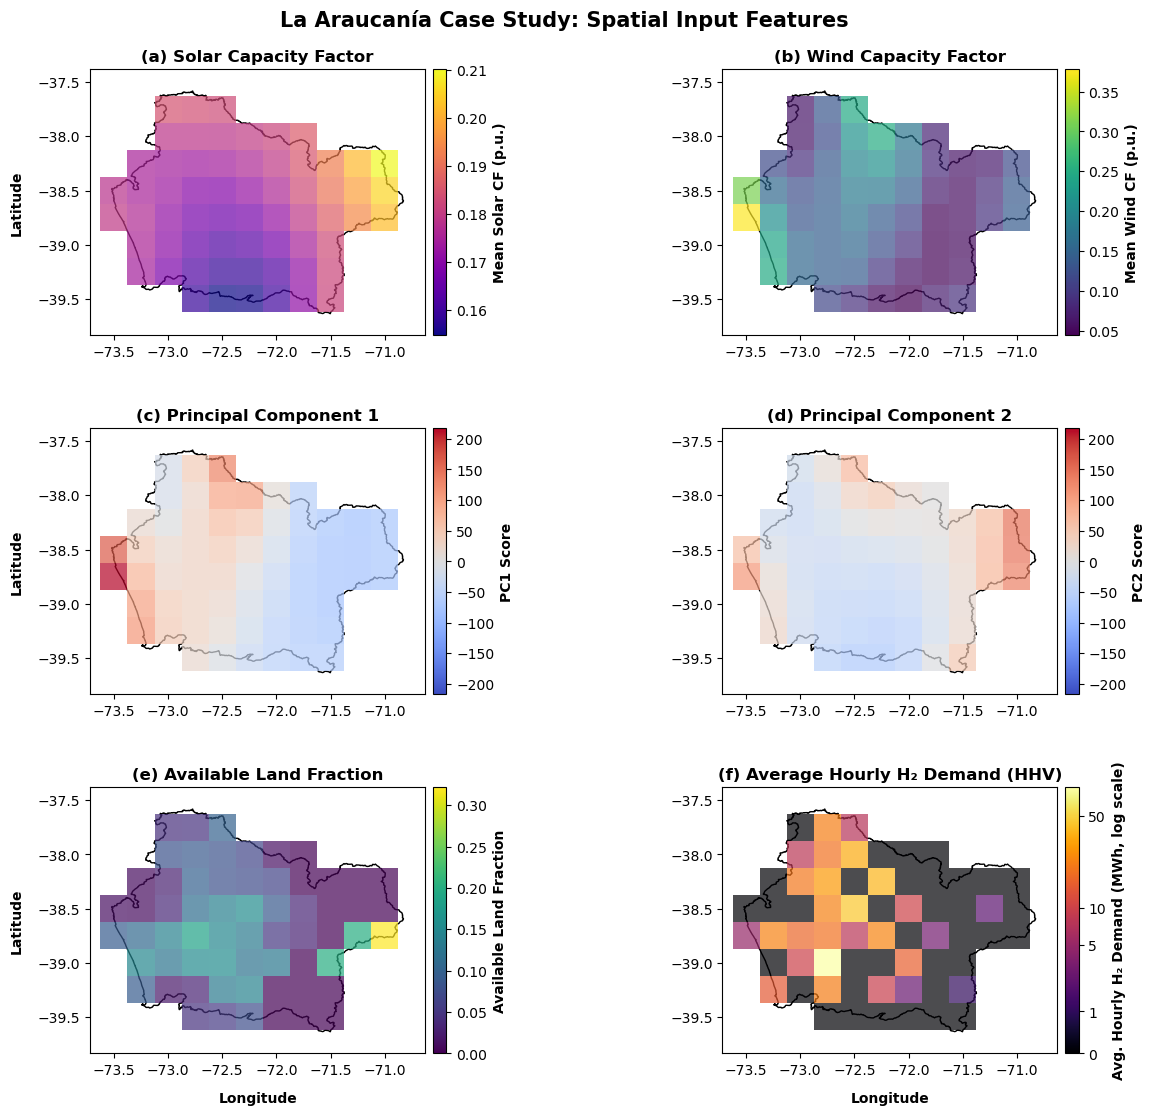

In [33]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import box
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── Load data ──
attrs   = pd.read_csv('../data_Araucania/CHI_ARN_attributes.csv')
outline = gpd.read_file('../data_Araucania/CHI_ARN_boundary.geojson')

half = 0.125
attrs['geometry'] = attrs.apply(
    lambda r: box(r['lon'] - half, r['lat'] - half, r['lon'] + half, r['lat'] + half), axis=1
)
gdf = gpd.GeoDataFrame(attrs, geometry='geometry', crs='EPSG:4326')

gdf['log_demand'] = np.log1p(gdf['avg_h2_demand_MWh'].abs())
pc_abs_max = max(gdf['pc1'].abs().max(), gdf['pc2'].abs().max())

# ── Figure setup ──
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.subplots_adjust(hspace=0.35, wspace=0.04, top=0.93)   # more vertical, less horizontal, tighten top gap

plot_configs = [
    {'ax': axes[0, 0], 'col': 'solar_cf_mean',           'cmap': 'plasma',   'label': 'Mean Solar CF (p.u.)',                   'title': '(a) Solar Capacity Factor',   'log': False, 'shared_norm': None},
    {'ax': axes[0, 1], 'col': 'wind_cf_mean',            'cmap': 'viridis',  'label': 'Mean Wind CF (p.u.)',                    'title': '(b) Wind Capacity Factor',    'log': False, 'shared_norm': None},
    {'ax': axes[1, 0], 'col': 'pc1',                     'cmap': 'coolwarm', 'label': 'PC1 Score',                              'title': '(c) Principal Component 1',   'log': False, 'shared_norm': mcolors.Normalize(vmin=-pc_abs_max, vmax=pc_abs_max)},
    {'ax': axes[1, 1], 'col': 'pc2',                     'cmap': 'coolwarm', 'label': 'PC2 Score',                              'title': '(d) Principal Component 2',   'log': False, 'shared_norm': mcolors.Normalize(vmin=-pc_abs_max, vmax=pc_abs_max)},
    {'ax': axes[2, 0], 'col': 'available_land_fraction', 'cmap': 'viridis',  'label': 'Available Land Fraction',                'title': '(e) Available Land Fraction', 'log': False, 'shared_norm': None},
    {'ax': axes[2, 1], 'col': 'log_demand',              'cmap': 'inferno',  'label': 'Avg. Hourly H₂ Demand (MWh, log scale)',            'title': '(f) Average Hourly H₂ Demand (HHV)', 'log': True, 'shared_norm': None},
]

for cfg in plot_configs:
    ax  = cfg['ax']
    col = cfg['col']

    outline.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0, zorder=0)

    norm = cfg['shared_norm'] if cfg['shared_norm'] is not None else mcolors.Normalize(vmin=gdf[col].min(), vmax=gdf[col].max())

    gdf.plot(column=col, cmap=cfg['cmap'], norm=norm, ax=ax, alpha=0.7, edgecolor='none', legend=False)

    sm = plt.cm.ScalarMappable(cmap=cfg['cmap'], norm=norm)
    sm.set_array([])
    divider = make_axes_locatable(ax)
    cax  = divider.append_axes('right', size='4%', pad=0.08)
    cbar = fig.colorbar(sm, cax=cax)

    if cfg['log']:
        raw_max = gdf['avg_h2_demand_MWh'].abs().max()
        mwh_ticks = [v for v in [0, 1, 5, 10, 50, 100] if v <= raw_max * 1.1 or v == 0]
        cbar.set_ticks([np.log1p(v) for v in mwh_ticks])
        cbar.set_ticklabels(mwh_ticks)

    cbar.set_label(cfg['label'], fontsize=10, fontweight='bold')   # bold colorbar labels

    ax.set_title(cfg['title'], fontsize=12, fontweight='bold')
    ax.set_xlim(outline.total_bounds[0] - 0.2, outline.total_bounds[2] + 0.2)
    ax.set_ylim(outline.total_bounds[1] - 0.2, outline.total_bounds[3] + 0.2)
    ax.set_aspect('equal')
    row_idx, col_idx = np.argwhere(axes == ax)[0]
    ax.set_xlabel('Longitude' if row_idx == 2 else '', labelpad=10, fontweight='bold')   # bold axis labels
    ax.set_ylabel('Latitude'  if col_idx == 0 else '', labelpad=10, fontweight='bold')

plt.suptitle('La Araucanía Case Study: Spatial Input Features', fontsize=15, fontweight='bold')
plt.savefig('../Cluster_Output_Araucania/3x2_attributes_araucania.png', dpi=300, bbox_inches='tight')
plt.show()

k=3: LCOH = 6.06 $/kg
k=6: LCOH = 5.79 $/kg
k=9: LCOH = 5.57 $/kg
k=12: LCOH = 5.53 $/kg


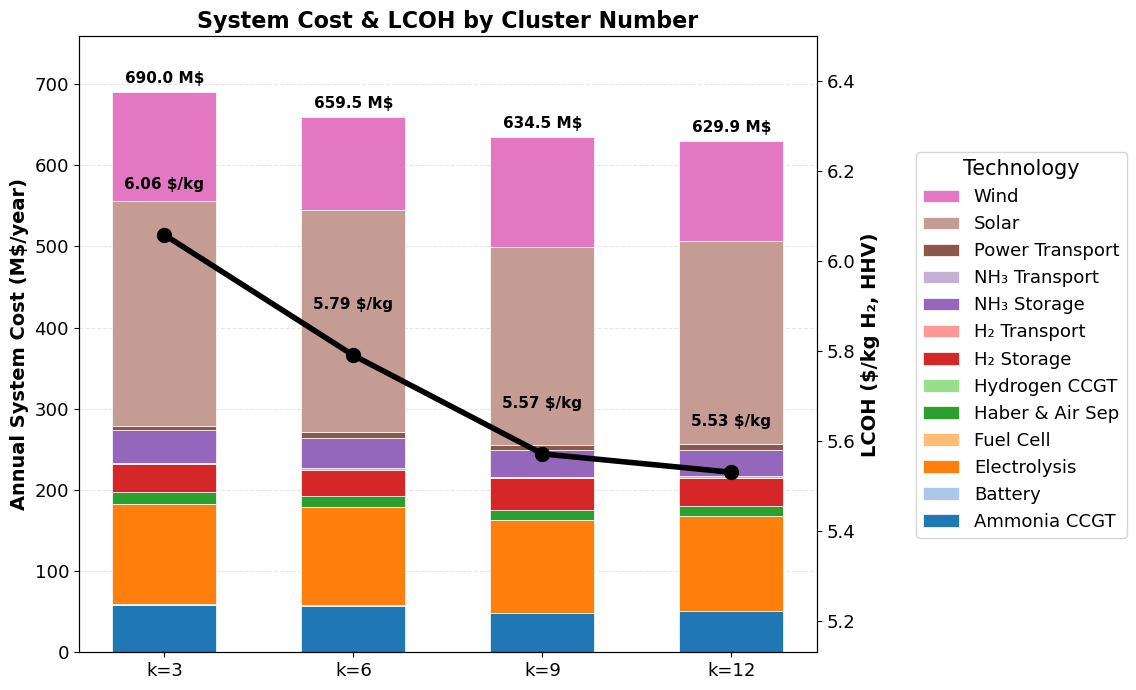

In [34]:
labels     = list(runs.keys())
n          = len(labels)
x          = np.arange(n)
colors     = plt.cm.tab20.colors
cat_colors = {cat: colors[i % len(colors)] for i, cat in enumerate(all_categories)}

fig, ax1 = plt.subplots(figsize=(12, 7))

# ── Left axis: stacked cost bars ──────────────────────────────────────────────
bottom = np.zeros(n)
for cat in all_categories:
    values = cost_matrix.loc[cat].values / 1e3
    ax1.bar(x, values, bottom=bottom, label=cat, color=cat_colors[cat],
            edgecolor='white', linewidth=0.5, width=0.55)
    bottom += values

global_max = (cost_matrix.sum() / 1e3).max() * 1.1
for i, label in enumerate(labels):
    total = cost_matrix[label].sum() / 1e3
    ax1.text(i, total + global_max * 0.01, f'{total:.1f} M$',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=13)
ax1.set_ylabel('Annual System Cost (M$/year)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelsize=13)
ax1.set_ylim(0, global_max)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.set_title('System Cost & LCOH by Cluster Number', fontsize=16, fontweight='bold')

# ── Right axis: LCOH line ─────────────────────────────────────────────────────
ax2 = ax1.twinx()
lcoh_vals = []
for label in labels:
    cost_k_dollar = total_costs[label]
    h2_kg         = total_h2[label] / H2_HHV_MWH_PER_KG
    lcoh_vals.append((cost_k_dollar * 1e3) / h2_kg)
    print(f"{label}: LCOH = {lcoh_vals[-1]:.2f} $/kg")

ax2.plot(x, lcoh_vals, color='black', marker='o', linewidth=4,
         markersize=10, zorder=5, label='LCOH')

lcoh_min = min(lcoh_vals)
lcoh_max = max(lcoh_vals)
pad = (lcoh_max - lcoh_min) * 0.5 if lcoh_max != lcoh_min else 0.45
ax2.set_ylim(lcoh_min - 0.4, 6.5)

# Labels above each marker, centred, with units
label_offset = (ax2.get_ylim()[1] - ax2.get_ylim()[0]) * 0.07
for i, v in enumerate(lcoh_vals):
    ax2.text(i, v + label_offset, f'{v:.2f} $/kg',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

ax2.set_ylabel('LCOH ($/kg H₂, HHV)', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelsize=13)
ax2.yaxis.grid(False)

# ── Legends ───────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
lcoh_handle = Line2D([0], [0], color='black', marker='o', linewidth=2, markersize=10, label='LCOH ($/kg H₂)')

# ── Legend — right side, vertically centred ───────────────────────────────────
bar_handles, bar_labels = ax1.get_legend_handles_labels()
fig.legend(bar_handles[::-1], bar_labels[::-1],
           title='Technology',
           loc='center left',
           bbox_to_anchor=(0.76, 0.5),
           fontsize=13, title_fontsize=15,
           frameon=True)

plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.savefig('../Cluster_Output_Araucania/cost_lcoh_dualaxis.png', dpi=150, bbox_inches='tight')
plt.show()

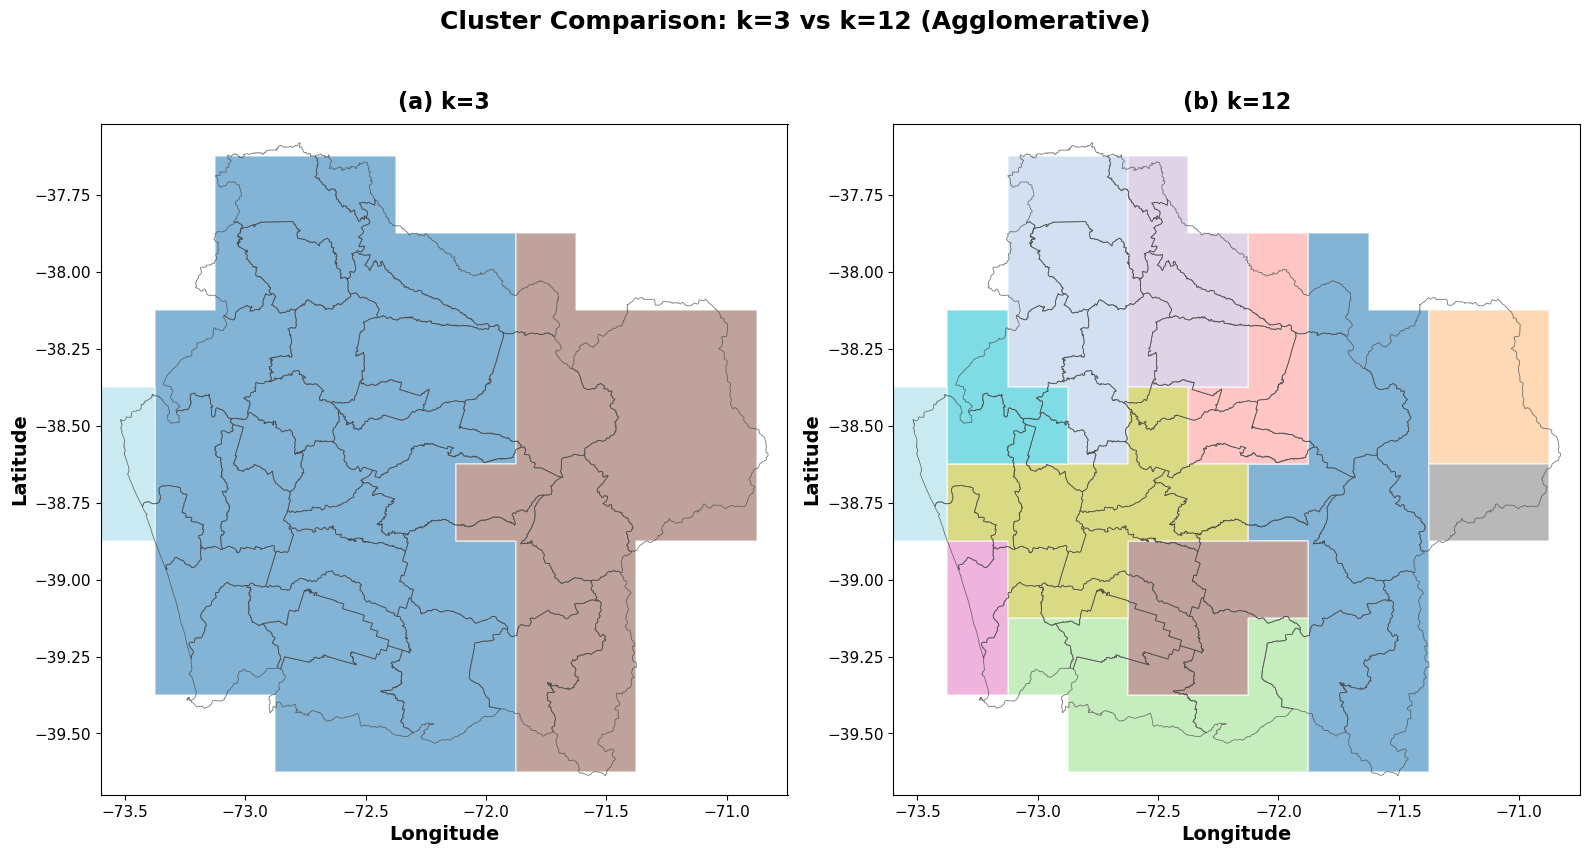

In [35]:
communes = gpd.read_file(
    '../data_Araucania/araucania_communes/araucania_communes.shp'
).to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
cmap = plt.cm.tab20

for ax, (label, k_str) in zip(axes, [('(a) k=3', '3'), ('(b) k=12', '12')]):
    geodata_path = f'{base_dir}/Agglomerative_k{k_str}/clusters_geodata.geojson'
    clusters_gdf = gpd.read_file(geodata_path).to_crs("EPSG:4326")

    cluster_ids = sorted(clusters_gdf['cluster'].unique())

    # ── Cluster fill ──────────────────────────────────────────────────────
    clusters_dissolved = clusters_gdf.dissolve(by='cluster').reset_index()
    for _, row in clusters_dissolved.iterrows():
        cid   = int(row['cluster'])
        color = cmap(cid / max(cluster_ids))
        gpd.GeoDataFrame([row], geometry='geometry', crs="EPSG:4326").plot(
            ax=ax, facecolor=color, edgecolor='white', linewidth=1.2,
            alpha=0.55, zorder=2
        )
        cx = row.geometry.centroid.x
        cy = row.geometry.centroid.y

    # ── Commune outlines ──────────────────────────────────────────────────
    communes.plot(ax=ax, facecolor='none', edgecolor='#444444',
                  linewidth=0.6, zorder=3, alpha=0.7)

    # ── Commune name labels ───────────────────────────────────────────────

    xmin, ymin, xmax, ymax = communes.total_bounds
    xpad, ypad = (xmax - xmin) * 0.03, (ymax - ymin) * 0.03
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(label,
                 fontsize=16, fontweight='bold', y = 1.01)
    ax.set_xlabel('Longitude', fontsize=14, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=14, fontweight='bold')
    ax.tick_params(labelsize=11)

plt.suptitle('Cluster Comparison: k=3 vs k=12 (Agglomerative)',
             fontsize=18, fontweight='bold', y=0.93)
plt.tight_layout()
plt.savefig('../Cluster_Output_Araucania/cluster_k3_k12_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

Loaded k = 3 and k = 12.


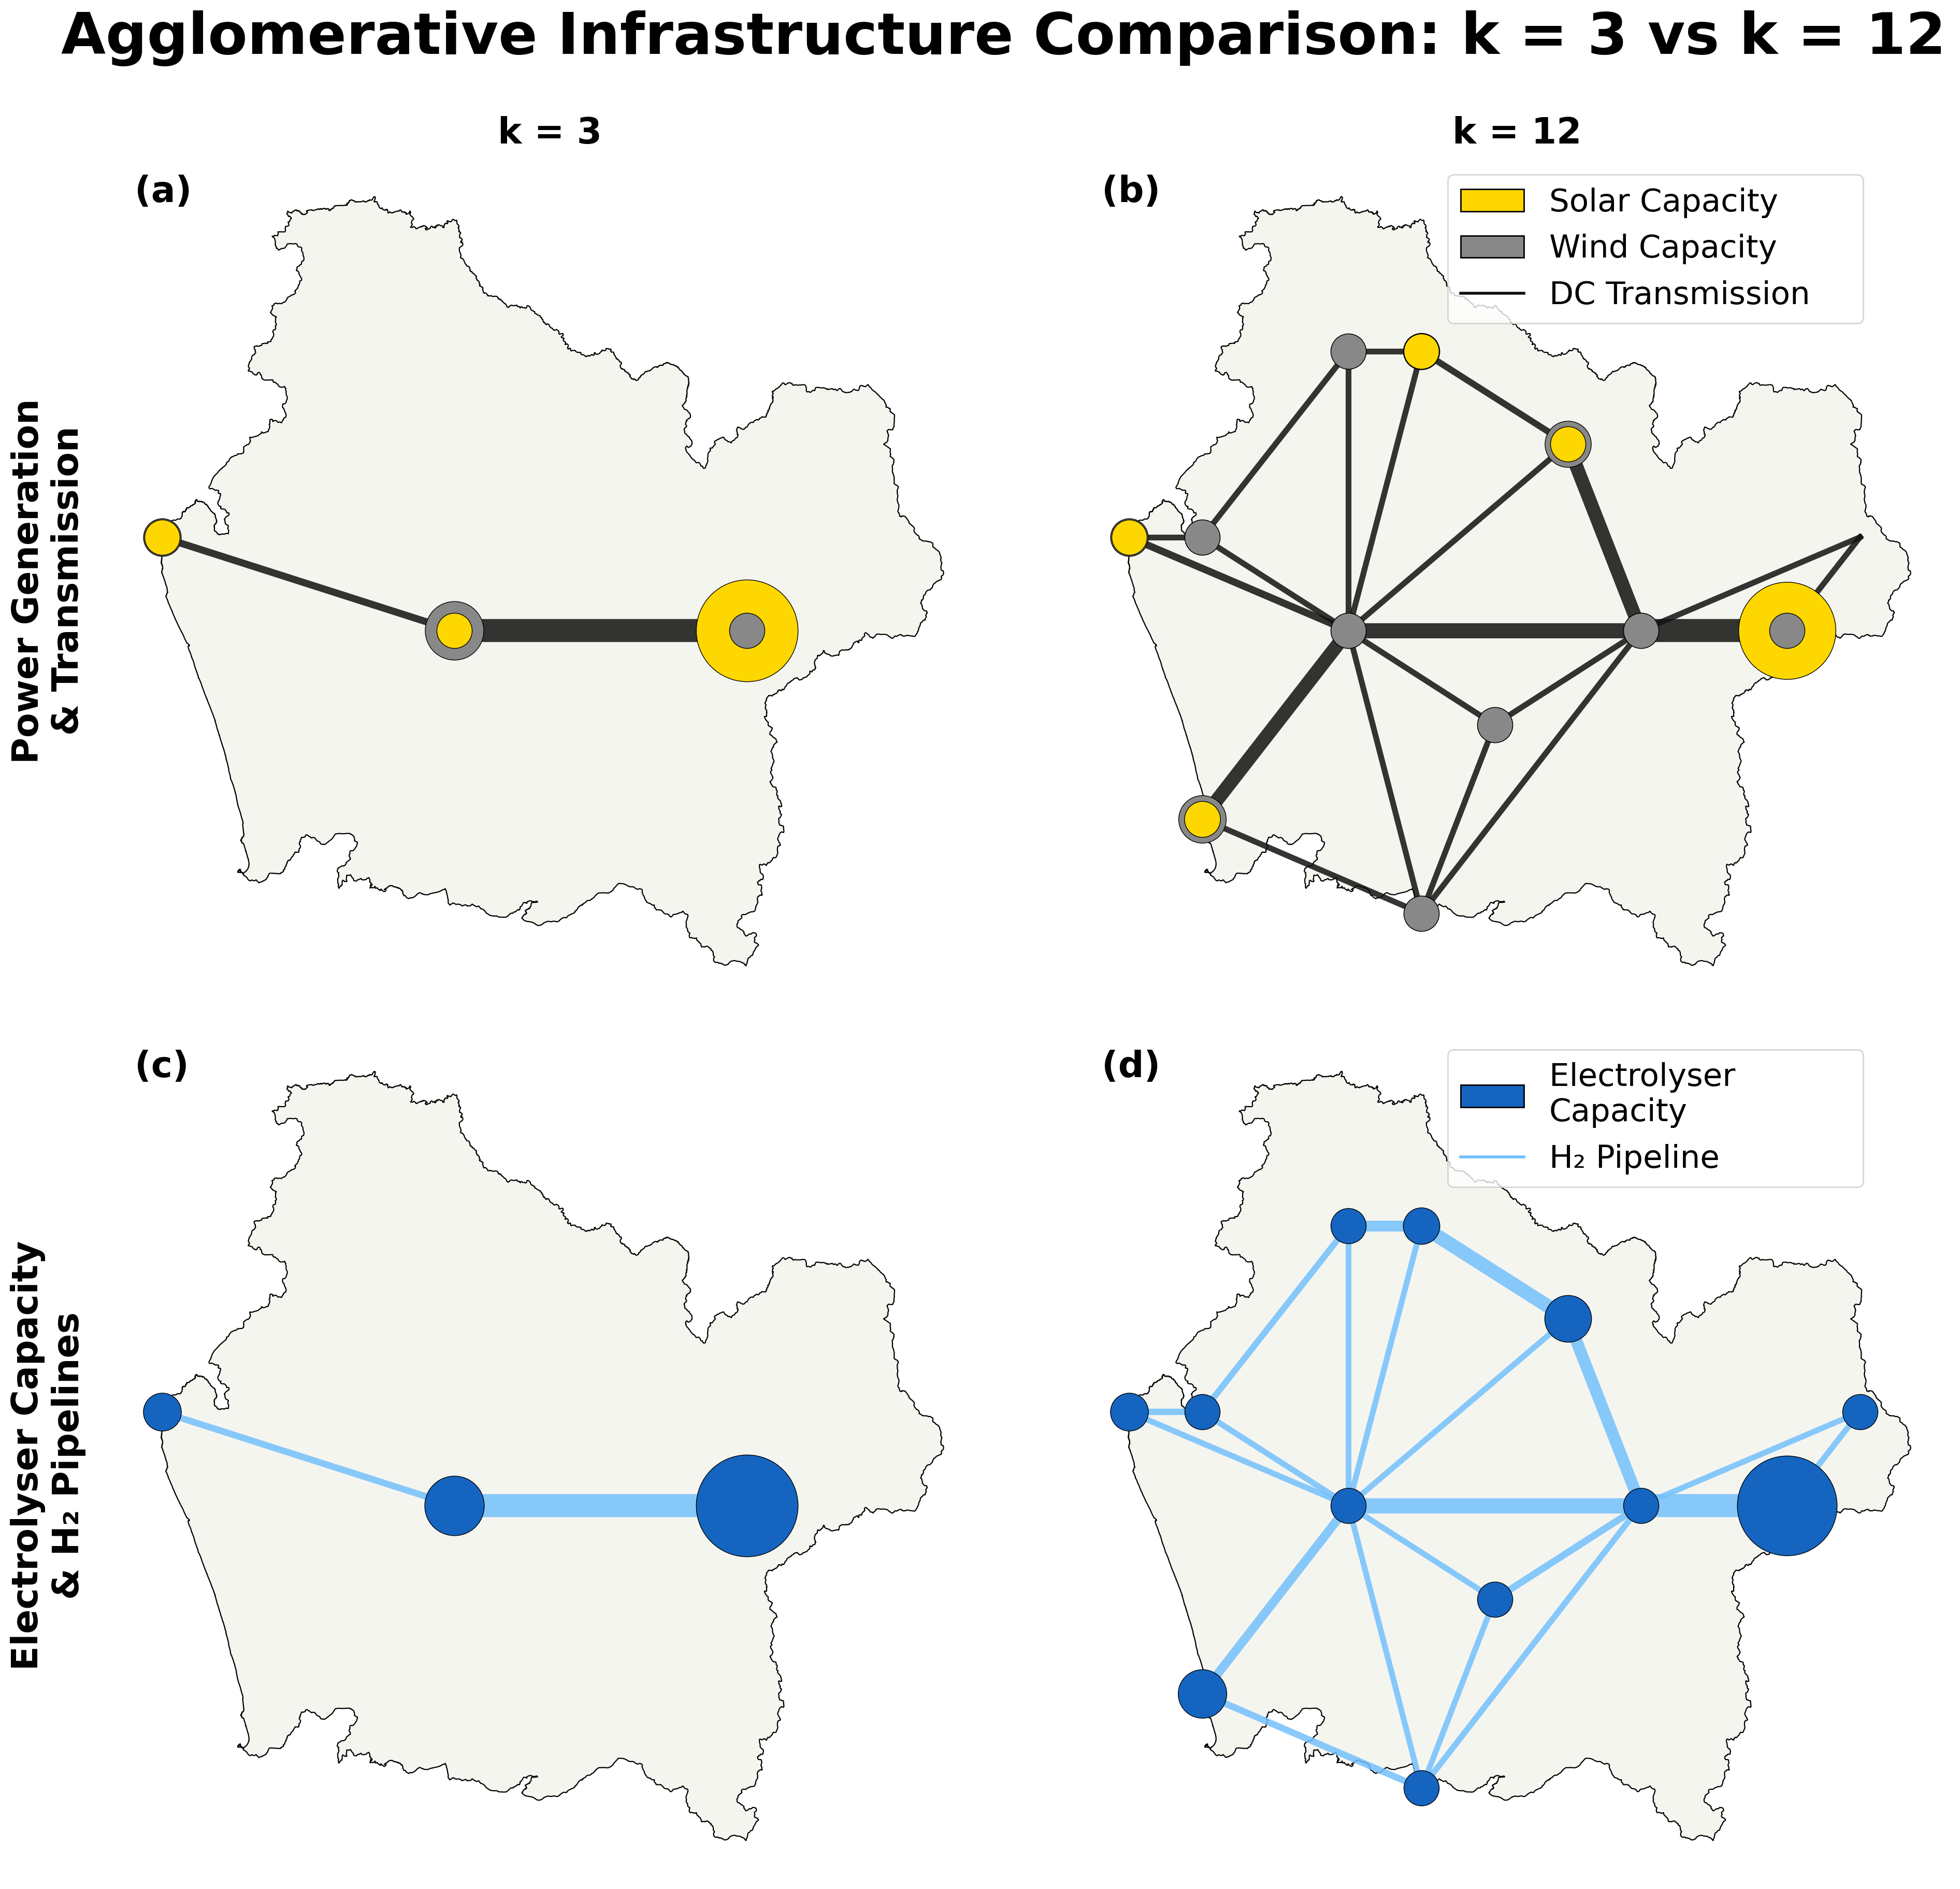

In [36]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

BOUNDARY_PATH = '../data_Araucania/CHI_ARN_boundary.geojson'
CRS = 'EPSG:3857'
MIN_S, MAX_S   = 600, 5000
MIN_LW, MAX_LW = 4, 16

def scale_to_common(series, common_max):
    if common_max == 0:
        return pd.Series(0, index=series.index)
    scaled = MIN_S + (MAX_S - MIN_S) * series.clip(lower=0) / common_max
    return scaled.where(series > 0, 0).clip(upper=MAX_S)

def scale_lw(series):
    mx = series.max()
    if mx == 0:
        return pd.Series(MIN_LW, index=series.index)
    return MIN_LW + (MAX_LW - MIN_LW) * series / mx

def make_node_name(lat, lon):
    return f"region_{str(round(lat, 2)).replace('.', '_')}_{str(round(lon, 2)).replace('.', '_')}"

boundary = gpd.read_file(BOUNDARY_PATH).to_crs(CRS)

# ── Load model data for k=3 and k=12 ──────────────────────────────────────────
k_data = {}
for k_str in ['3', '12']:
    b = f'../Cluster_Output_Araucania/Agglomerative/Agglomerative_k{k_str}'
    meta = pd.read_csv(f'{b}/cluster_metadata.csv')
    meta['node_name'] = meta.apply(lambda r: make_node_name(r['lat'], r['lon']), axis=1)
    node_gdf = gpd.GeoDataFrame(meta, geometry=gpd.points_from_xy(meta['lon'], meta['lat']),
                                 crs='EPSG:4326').to_crs(CRS)
    node_pos = dict(zip(node_gdf['node_name'],
                        zip(node_gdf.geometry.x, node_gdf.geometry.y)))

    model = calliope.read_netcdf(
        f'{b}/weighted_percentile_timeseries/Araucania_Agglomerative_k{k_str}.nc'
    )
    ec_raw = model.results.energy_cap.to_dataframe().reset_index()
    ec_raw.columns = ['loc_techs', 'energy_cap']
    ec_raw = ec_raw[ec_raw['energy_cap'].notna()].copy()
    ec_raw['loc_from']  = ec_raw['loc_techs'].str.split('::').str[0]
    ec_raw['tech_rest'] = ec_raw['loc_techs'].str.split('::').str[1]
    ec_raw['tech']      = ec_raw['tech_rest'].str.split(':').str[0]
    ec_raw['loc_to']    = ec_raw['tech_rest'].apply(
        lambda s: s.split(':', 1)[1] if isinstance(s, str) and ':' in s else None
    )
    ec_point = ec_raw[ec_raw['loc_to'].isna()][['loc_from', 'tech', 'energy_cap']].rename(
        columns={'loc_from': 'loc'}
    ).copy()
    ec_trans = ec_raw[ec_raw['loc_to'].notna()][['loc_from', 'tech', 'loc_to', 'energy_cap']].copy()
    ec_trans['_key'] = ec_trans.apply(
        lambda r: tuple(sorted([r['loc_from'], r['loc_to']])) + (r['tech'],), axis=1
    )
    ec_trans = (ec_trans.drop_duplicates(subset='_key')
                        .drop(columns='_key')
                        .reset_index(drop=True))
    ec_trans = ec_trans[ec_trans['energy_cap'] > 0].reset_index(drop=True)
    del model; gc.collect()

    k_data[k_str] = {'node_pos': node_pos, 'ec_point': ec_point, 'ec_trans': ec_trans}

print("Loaded k = 3 and k = 12.")

# ── Helpers ────────────────────────────────────────────────────────────────────
def get_caps(ec_point, tech_list):
    return ec_point[ec_point['tech'].isin(tech_list)].groupby('loc')['energy_cap'].sum()

def draw_links(ax, ec_trans, tech, color, node_pos):
    df = ec_trans[ec_trans['tech'] == tech]
    if df.empty: return
    lws = scale_lw(df['energy_cap']).values
    for (_, row), lw in zip(df.iterrows(), lws):
        p1, p2 = node_pos.get(row['loc_from']), node_pos.get(row['loc_to'])
        if p1 and p2:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color,
                    linewidth=lw, zorder=2, alpha=0.85)

def draw_two_markers(ax, caps_a, caps_b, col_a, col_b, common_max, node_pos):
    for name, (x, y) in node_pos.items():
        s_a = scale_to_common(pd.Series([caps_a.get(name, 0)]), common_max).iloc[0]
        s_b = scale_to_common(pd.Series([caps_b.get(name, 0)]), common_max).iloc[0]
        if s_a >= s_b:
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=3)
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=4)
        else:
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=3)
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=4)

def draw_single_markers(ax, caps, color, common_max, node_pos):
    for name, (x, y) in node_pos.items():
        s = scale_to_common(pd.Series([caps.get(name, 0)]), common_max).iloc[0]
        if s > 0:
            ax.scatter(x, y, s=s, color=color, edgecolors='k', linewidths=0.5, zorder=3)

# ── Global scale maxima ────────────────────────────────────────────────────────
all_solar = pd.concat([get_caps(k_data[k]['ec_point'], ['solar_single_axis']) for k in ['3', '12']])
all_wind  = pd.concat([get_caps(k_data[k]['ec_point'], ['onshore_wind'])      for k in ['3', '12']])
all_elec  = pd.concat([get_caps(k_data[k]['ec_point'], ['electrolyser'])      for k in ['3', '12']])
common_max_power = max(all_solar.max() if not all_solar.empty else 0,
                       all_wind.max()  if not all_wind.empty  else 0)
common_max_elec  = all_elec.max() if not all_elec.empty else 1

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 18), dpi=200)
fig.suptitle('Agglomerative Infrastructure Comparison: k = 3 vs k = 12',
             fontsize=40, fontweight='bold', y=1.01)

panel_labels = {(0, 0): '(a)', (0, 1): '(b)', (1, 0): '(c)', (1, 1): '(d)'}

for col_idx, k_str in enumerate(['3', '12']):
    node_pos = k_data[k_str]['node_pos']
    ec_point = k_data[k_str]['ec_point']
    ec_trans = k_data[k_str]['ec_trans']
    k_label  = f'k = {k_str}'

    # ── Row 0: Power generation + DC transmission ──────────────────────────
    ax = axes[0, col_idx]
    boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
    draw_links(ax, ec_trans, 'dc_transmission', '#111111', node_pos)
    draw_two_markers(ax,
                     get_caps(ec_point, ['solar_single_axis']),
                     get_caps(ec_point, ['onshore_wind']),
                     '#FFD700', '#888888', common_max_power, node_pos)
    ax.set_title(k_label, fontsize=25, fontweight='bold', pad=10)
    ax.set_axis_off()
    ax.text(0.02, 0.98, panel_labels[(0, col_idx)], transform=ax.transAxes,
            fontsize=25, fontweight='bold', va='top', ha='left', zorder=10)
    if col_idx == 1:
        ax.legend(handles=[
            Patch(facecolor='#FFD700', edgecolor='k', label='Solar Capacity'),
            Patch(facecolor='#888888', edgecolor='k', label='Wind Capacity'),
            Line2D([0], [0], color='#111111', linewidth=2, label='DC Transmission'),
            ], fontsize=22, bbox_to_anchor=(0.42, 0.98, 0.48, 0.0),
            loc='upper left', mode='expand', borderaxespad=0)

    # ── Row 1: Electrolyser + H₂ pipeline ─────────────────────────────────
    ax = axes[1, col_idx]
    boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
    draw_links(ax, ec_trans, 'hydrogen_pipeline', '#74c0fc', node_pos)
    draw_single_markers(ax, get_caps(ec_point, ['electrolyser']),
                        '#1565C0', common_max_elec, node_pos)
    ax.set_axis_off()
    ax.text(0.02, 0.98, panel_labels[(1, col_idx)], transform=ax.transAxes,
            fontsize=25, fontweight='bold', va='top', ha='left', zorder=10)
    if col_idx == 1:
        ax.legend(handles=[
            Patch(facecolor='#1565C0', edgecolor='k', label='Electrolyser\nCapacity'),
            Line2D([0], [0], color='#74c0fc', linewidth=2, label='H₂ Pipeline'),
            ], fontsize=22, bbox_to_anchor=(0.42, 0.98, 0.48, 0.0),
            loc='upper left', mode='expand', borderaxespad=0)

# ── Row labels on left column ──────────────────────────────────────────────────
axes[0, 0].text(-0.08, 0.5, 'Power Generation\n& Transmission',
                transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center',
                fontsize=25, fontweight='bold')
axes[1, 0].text(-0.08, 0.5, 'Electrolyser Capacity\n& H₂ Pipelines',
                transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center',
                fontsize=25, fontweight='bold')

plt.tight_layout(h_pad=2)
plt.savefig('../Cluster_Output_Araucania/infrastructure_k3_k12_comparison.png',
            dpi=200, bbox_inches='tight')
plt.show()

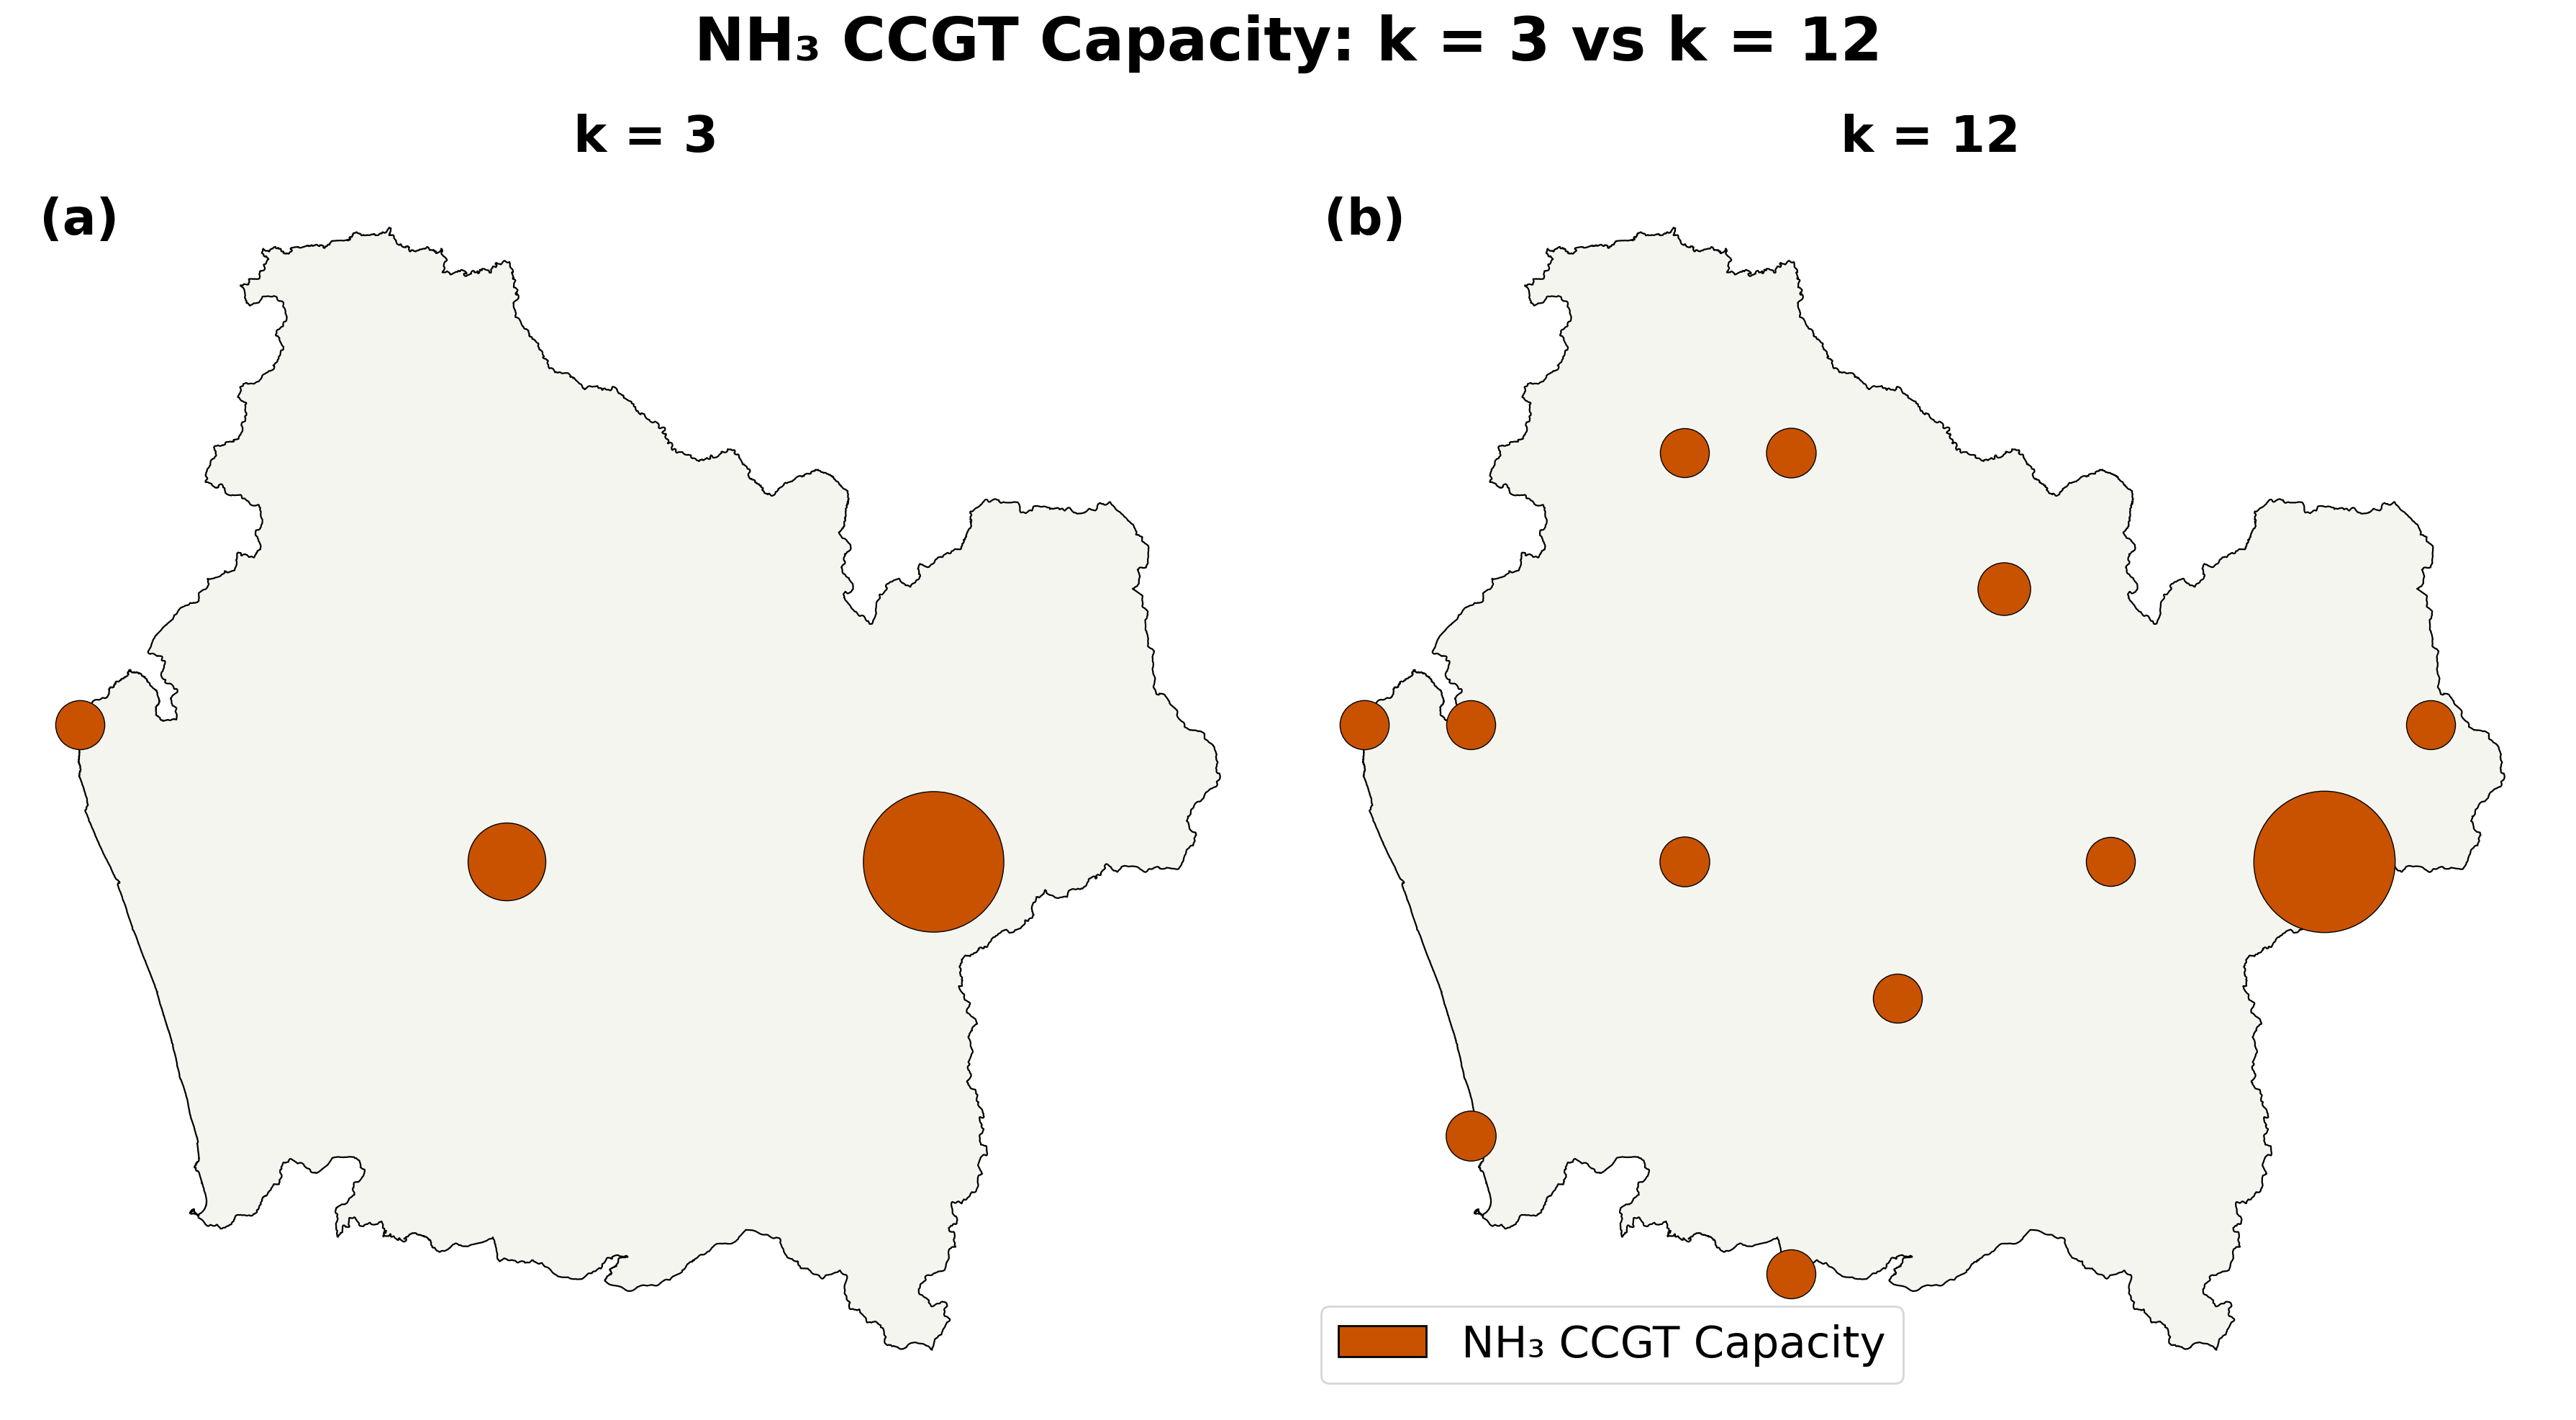

In [37]:
# ── NH₃ CCGT capacity: k=3 vs k=12 ───────────────────────────────────────────
all_ccgt = pd.concat([get_caps(k_data[k]['ec_point'], ['ammonia_ccgt']) for k in ['3', '12']])
common_max_ccgt = all_ccgt.max() if not all_ccgt.empty else 1

fig, axes = plt.subplots(1, 2, figsize=(18, 10), dpi=200)
fig.suptitle('NH₃ CCGT Capacity: k = 3 vs k = 12',
             fontsize=30, fontweight='bold', y=1.01)

for col_idx, k_str in enumerate(['3', '12']):
    ax = axes[col_idx]
    node_pos = k_data[k_str]['node_pos']
    ec_point = k_data[k_str]['ec_point']

    boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
    draw_single_markers(ax, get_caps(ec_point, ['ammonia_ccgt']),
                        '#c85200', common_max_ccgt, node_pos)
    ax.set_title(f'k = {k_str}', fontsize=25, fontweight='bold', pad=10)
    ax.set_axis_off()
    ax.text(0.02, 0.98, '(a)' if col_idx == 0 else '(b)', transform=ax.transAxes,
            fontsize=25, fontweight='bold', va='top', ha='left', zorder=10)
    if col_idx == 1:
        ax.legend(handles=[
            Patch(facecolor='#c85200', edgecolor='k', label='NH₃ CCGT Capacity'),
        ], fontsize=22, loc='lower left')

plt.tight_layout()
# plt.savefig('../Cluster_Output_Araucania/ammonia_ccgt_k3_k12.png',
#             dpi=200, bbox_inches='tight')
plt.show()

k=3: loaded storage_cap
k=12: loaded storage_cap


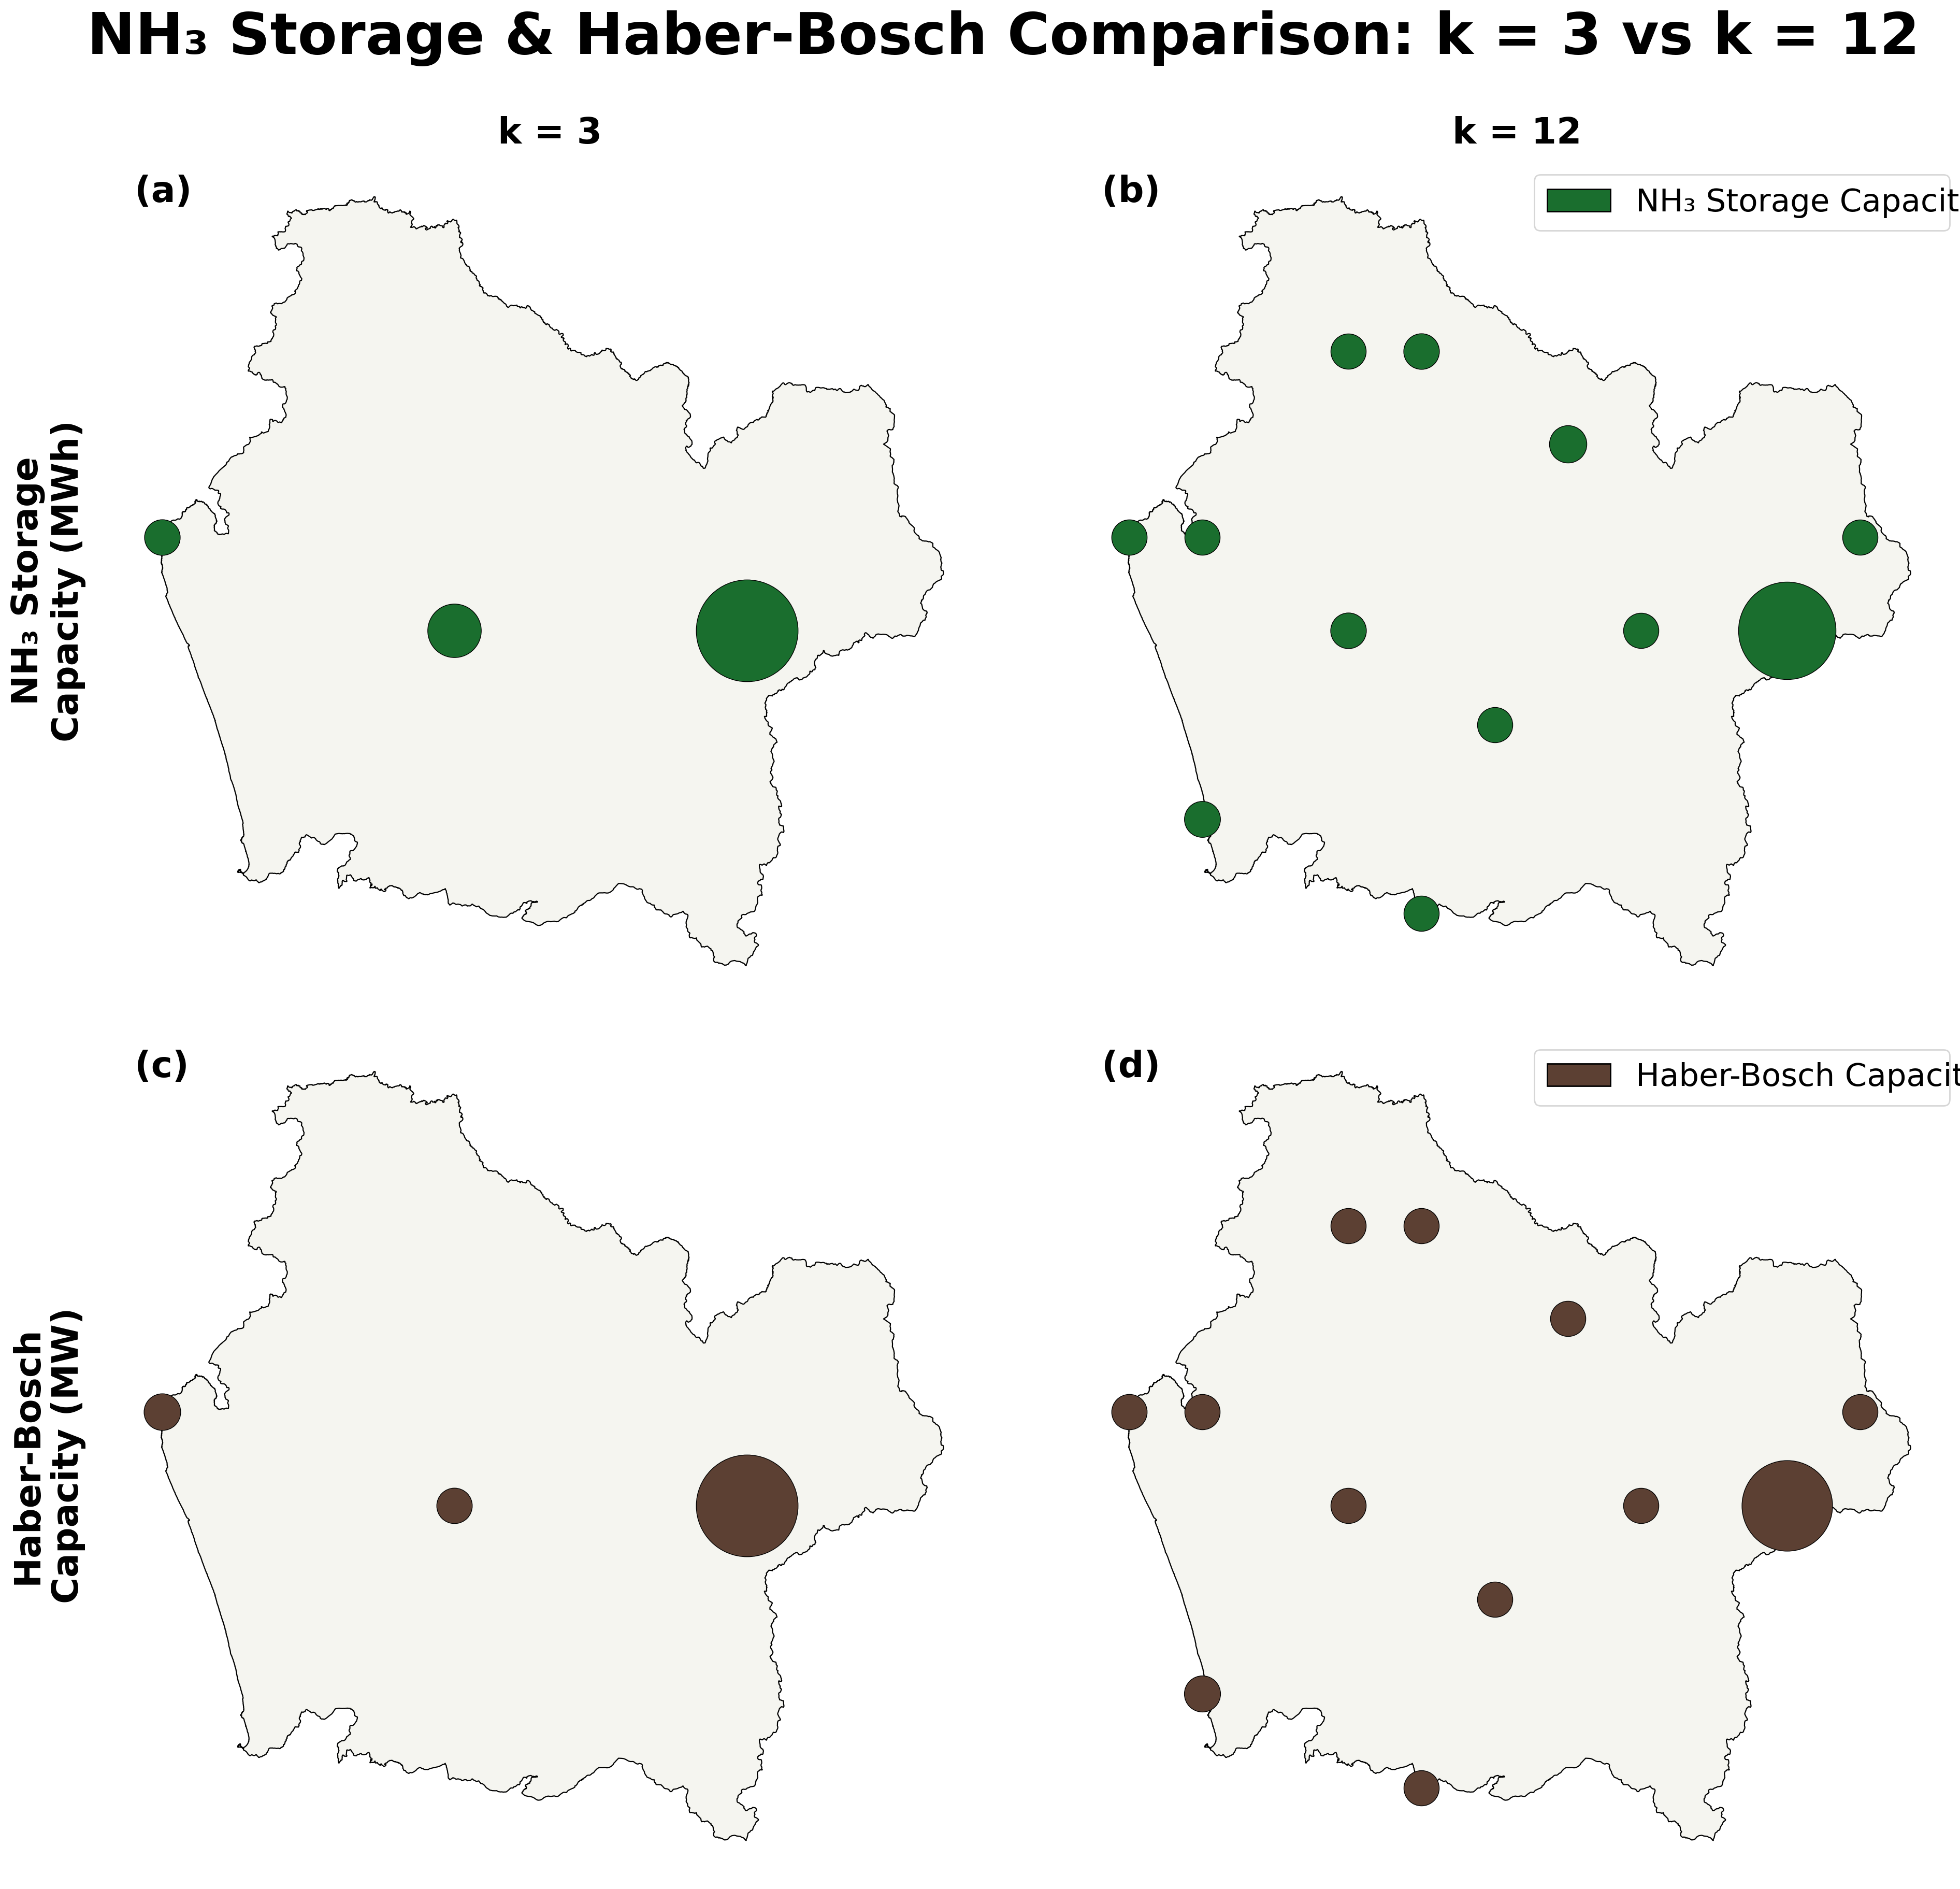

In [38]:
# ── NH₃ Storage (MWh) & Haber-Bosch (MW): k=3 vs k=12 ───────────────────────
import calliope, gc

# Reload models to extract storage_cap for ammonia_storage
sc_data = {}
for k_str in ['3', '12']:
    b = f'../Cluster_Output_Araucania/Agglomerative/Agglomerative_k{k_str}'
    model = calliope.read_netcdf(
        f'{b}/weighted_percentile_timeseries/Araucania_Agglomerative_k{k_str}.nc'
    )
    sc_raw = model.results.storage_cap.to_dataframe().reset_index()
    sc_raw.columns = ['loc_techs', 'storage_cap']
    sc_raw = sc_raw[sc_raw['storage_cap'].notna()].copy()
    sc_raw['loc']  = sc_raw['loc_techs'].str.split('::').str[0]
    sc_raw['tech'] = sc_raw['loc_techs'].str.split('::').str[1]
    del model; gc.collect()
    sc_data[k_str] = sc_raw
    print(f"k={k_str}: loaded storage_cap")

def get_storage_caps_sc(sc_raw, tech_list, node_pos):
    df = sc_raw[sc_raw['tech'].isin(tech_list)]
    return df.groupby('loc')['storage_cap'].sum()

# ── Shared scale maxima ────────────────────────────────────────────────────────
all_nh3_storage = pd.concat([
    get_storage_caps_sc(sc_data[k], ['ammonia_storage'], k_data[k]['node_pos'])
    for k in ['3', '12']
])
all_haber = pd.concat([get_caps(k_data[k]['ec_point'], ['haber_and_air_separation']) for k in ['3', '12']])
common_max_nh3_storage = all_nh3_storage.max() if not all_nh3_storage.empty else 1
common_max_haber       = all_haber.max()        if not all_haber.empty        else 1

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 18), dpi=200)
fig.suptitle('NH₃ Storage & Haber-Bosch Comparison: k = 3 vs k = 12',
             fontsize=40, fontweight='bold', y=1.01)

panel_labels_hb = {(0, 0): '(a)', (0, 1): '(b)', (1, 0): '(c)', (1, 1): '(d)'}

for col_idx, k_str in enumerate(['3', '12']):
    node_pos = k_data[k_str]['node_pos']
    ec_point = k_data[k_str]['ec_point']
    sc_raw   = sc_data[k_str]
    k_label  = f'k = {k_str}'

    # ── Row 0: NH₃ Storage (MWh) ──────────────────────────────────────────
    ax = axes[0, col_idx]
    boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
    draw_single_markers(ax, get_storage_caps_sc(sc_raw, ['ammonia_storage'], node_pos),
                        '#1a6e2e', common_max_nh3_storage, node_pos)
    ax.set_title(k_label, fontsize=25, fontweight='bold', pad=10)
    ax.set_axis_off()
    ax.text(0.02, 0.98, panel_labels_hb[(0, col_idx)], transform=ax.transAxes,
            fontsize=25, fontweight='bold', va='top', ha='left', zorder=10)
    if col_idx == 1:
        ax.legend(handles=[
            Patch(facecolor='#1a6e2e', edgecolor='k', label='NH₃ Storage Capacity'),
        ], fontsize=22, bbox_to_anchor=(0.52, 0.98, 0.48, 0.0),
        loc='upper left', mode='expand', borderaxespad=0)

    # ── Row 1: Haber-Bosch (MW) ───────────────────────────────────────────
    ax = axes[1, col_idx]
    boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
    draw_single_markers(ax, get_caps(ec_point, ['haber_and_air_separation']),
                        '#5c4033', common_max_haber, node_pos)
    ax.set_axis_off()
    ax.text(0.02, 0.98, panel_labels_hb[(1, col_idx)], transform=ax.transAxes,
            fontsize=25, fontweight='bold', va='top', ha='left', zorder=10)
    if col_idx == 1:
        ax.legend(handles=[
            Patch(facecolor='#5c4033', edgecolor='k', label='Haber-Bosch Capacity'),
        ], fontsize=22, bbox_to_anchor=(0.52, 0.98, 0.48, 0.0),
        loc='upper left', mode='expand', borderaxespad=0)

# ── Row labels ────────────────────────────────────────────────────────────────
axes[0, 0].text(-0.08, 0.5, 'NH₃ Storage\nCapacity (MWh)',
                transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center',
                fontsize=25, fontweight='bold')
axes[1, 0].text(-0.08, 0.5, 'Haber-Bosch\nCapacity (MW)',
                transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center',
                fontsize=25, fontweight='bold')

plt.tight_layout(h_pad=2)
plt.savefig('../Cluster_Output_Araucania/nh3_storage_haber_k3_k12.png',
            dpi=200, bbox_inches='tight')
plt.show()

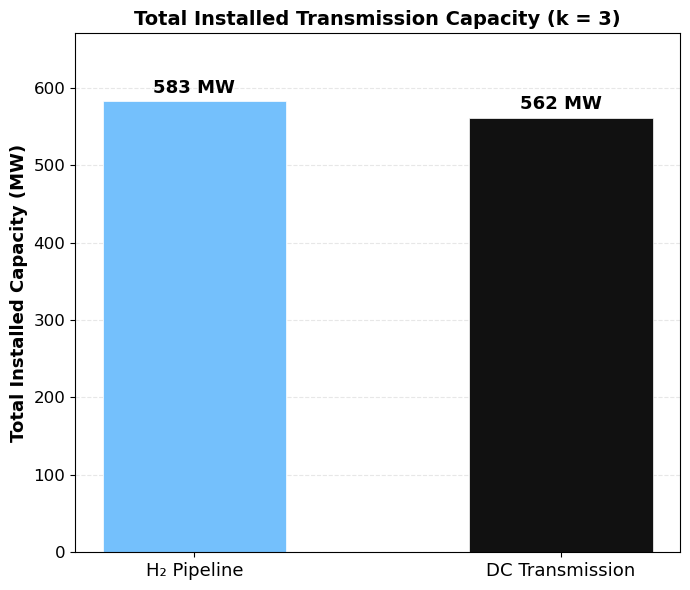

In [39]:
# ── Total installed transmission capacity: k=3 ───────────────────────────────
ec_trans_k3 = k_data['3']['ec_trans']

total_h2_pipe = ec_trans_k3[ec_trans_k3['tech'] == 'hydrogen_pipeline']['energy_cap'].sum()
total_dc_trans = ec_trans_k3[ec_trans_k3['tech'] == 'dc_transmission']['energy_cap'].sum()

techs  = ['H₂ Pipeline', 'DC Transmission']
values = [total_h2_pipe, total_dc_trans]
colors = ['#74c0fc', '#111111']

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(techs, values, color=colors, edgecolor='white', linewidth=0.5, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(values) * 0.01,
            f'{val:.0f} MW', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Total Installed Capacity (MW)', fontsize=13, fontweight='bold')
ax.set_title('Total Installed Transmission Capacity (k = 3)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
plt.savefig('../Cluster_Output_Araucania/transmission_totals_k3.png', dpi=150, bbox_inches='tight')
plt.show()